# MemoRAG on LongMemEval: an RWKV-7 memory model as a retrieval clue generator

This notebook adapts **MemoRAG** (Qian et al., *MemoRAG: Boosting Long Context Processing with
Global Memory-Enhanced Retrieval Augmentation*, arXiv:2409.05591) to
[LongMemEval](https://arxiv.org/abs/2410.10813) (Wu et al., ICLR 2025), replacing MemoRAG's own
memory model with an RNN from the **RWKV-7** family
([rwkv7-g1i-2.9b-20260805-ctx16384](https://huggingface.co/BlinkDL/rwkv7-g1), the same weights
published at [RWKV/RWKV7-2.9B-20260805](https://huggingface.co/RWKV/RWKV7-2.9B-20260805) -- see
Section 23 for why this notebook uses the `.pth`/`rwkv`-package path rather than the safetensors
conversion).

**The question this notebook answers.** MemoRAG's core idea is that a cheap memory model, given a
*global* view of a corpus, can generate better retrieval queries than the raw user question --
because it can name things the question itself only implies. RWKV's constant-size recurrent state
is a natural fit for "global view": feeding an entire document into it costs no more memory than
feeding one sentence. Does that combination -- RWKV's state as MemoRAG's memory model -- help a
downstream reader answer LongMemEval questions better than retrieving with the bare question alone,
**at an equal evidence budget**?

**Why `longmemeval_recreation.ipynb`'s `Llama-3.2-1B-Instruct` row is the right first test.** That
notebook's Table 8 measured, for this reader: oracle **0.386**, full LongMemEval_S long-context
**0.010** (collapses to the floor -- 115k tokens is far beyond what a 1B model can use), retrieval
with a simple key design **0.312**. Essentially all of this reader's achievable accuracy comes from
*which sessions it is shown*, not from reasoning over more text -- which makes it the cleanest place
to isolate a retrieval-quality effect from a reading-capacity effect. `READERS` below is a dict
specifically so that repeating this analysis for the recreation notebook's other four readers, once
this one is validated, is a config change, not a rewrite.

**What is transcribed, and from where.** Nothing here is copied blind. Every string taken from
LongMemEval's own repository or from MemoRAG's own repository is checked against that repository's
*live* source in Sections 7-8 (Gate 2a/2b) before anything downstream trusts it -- the same
discipline `longmemeval_recreation.ipynb`'s own Gate 2 uses. Section 23 states every place this
notebook's design deviates from either paper's exact methodology, and audits `new_method.ipynb` --
an earlier, narrower attempt at this same idea -- against MemoRAG's real mechanism.

**Colab-only, A100 recommended.** Like `longmemeval_recreation.ipynb`, this notebook fails fast if
Drive or a GPU is missing rather than limping along. Section 1 explains why.


## Section 1: Environment

This notebook needs Google Drive (everything it writes -- the RWKV checkpoint, embedding caches,
generations, judgements -- lives there, so a dropped Colab runtime loses at most the in-flight
chunk) and a GPU with meaningful VRAM. Three models are used, but never at the same time (Section
3's staging design): RWKV-7 G1 2.9B (~5.9GB in fp16), Stella V5 1.5B (~3GB), and Llama-3.2-1B via
vLLM (~2.5GB weights, plus whatever KV-cache pool `gpu_memory_utilization` reserves). An A100-40GB
comfortably fits any one of these with headroom to spare; nothing here needs multi-GPU or an
A100-80GB.

Every `print()` in this notebook is teed to a log file on Drive in append mode, so a trace of what
happened survives a dropped runtime even though the Colab session itself is gone.


In [1]:
import os, sys, subprocess, json, math, time, hashlib, random, re, gc
from pathlib import Path
from datetime import datetime, timezone

if "google.colab" not in sys.modules:
    raise RuntimeError(
        "This notebook is Colab-only -- there is no local execution path. Open it in Google "
        "Colab (Runtime > Change runtime type > pick a GPU, ideally A100) and run it there.")

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

REPO = Path("/content/drive/MyDrive/lme_memorag")
REPO.mkdir(parents=True, exist_ok=True)

# --- tee every print() to a Drive-backed log, same pattern as longmemeval_recreation.ipynb ------
LOG_PATH = REPO / "logs" / "run.log"
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

class _Tee:
    def __init__(self, *streams):
        self.streams = streams
    def write(self, data):
        for s in self.streams:
            s.write(data); s.flush()
    def flush(self):
        for s in self.streams:
            s.flush()
    def __getattr__(self, name):
        # ipykernel attributes output to the running cell via sys.stdout.set_parent(parent),
        # probed with hasattr() -- without delegating unknown attributes to the real stream, that
        # probe silently fails and every later print() gets attributed to the cell that installed
        # the tee, then dropped by the frontend. The log file still fills; the notebook output does
        # not. Same fix as longmemeval_recreation.ipynb Section 1.
        if name == "streams":
            raise AttributeError(name)
        return getattr(self.streams[0], name)
    def fileno(self):
        for s in self.streams:
            try:
                return s.fileno()
            except (AttributeError, OSError, ValueError):
                continue
        raise OSError("no underlying fileno available")

if not isinstance(sys.stdout, _Tee):
    _log_fh = open(LOG_PATH, "a", encoding="utf-8")
    _log_fh.write(f"\n{'='*80}\n[{datetime.now(timezone.utc).isoformat()}] session (re)started\n{'='*80}\n")
    _log_fh.flush()
    sys.stdout = _Tee(sys.stdout, _log_fh)
    sys.stderr = _Tee(sys.stderr, _log_fh)

def detect_gpu():
    # No `import torch` here -- the first import of torch in this process locks that build into
    # sys.modules for the whole kernel, which would fight Section 2's CUDA-matched torch install.
    try:
        out = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader,nounits"],
            capture_output=True, text=True, check=True).stdout.strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None, 0.0
    if not out:
        return None, 0.0
    name, mib = out.splitlines()[0].split(",")
    return name.strip(), float(mib) / 1024

GPU_NAME, GPU_VRAM_GB = detect_gpu()
if GPU_NAME is None:
    raise RuntimeError("No GPU on this runtime. Runtime > Change runtime type > pick a GPU "
                       "(A100 recommended), then Runtime > Restart session and re-run from the top.")

CAN_RUN_LOCAL_READER = GPU_VRAM_GB >= 20     # Llama-3.2-1B via vLLM, generous headroom
CAN_RUN_RWKV         = GPU_VRAM_GB >= 12     # RWKV-7 G1 2.9B fp16
CAN_RUN_EMBEDDINGS   = GPU_VRAM_GB >= 8      # Stella V5 1.5B

print(f"Drive:      mounted, working folder {REPO}")
print(f"Log file:   {LOG_PATH}  (appends across sessions)")
print(f"GPU:        {GPU_NAME}  ({GPU_VRAM_GB:.1f} GB)")
print(f"Local reader (Llama-3.2-1B via vLLM): {'yes' if CAN_RUN_LOCAL_READER else 'NO'}")
print(f"RWKV-7 G1 2.9B:                       {'yes' if CAN_RUN_RWKV else 'NO'}")
print(f"Stella V5 embeddings:                 {'yes' if CAN_RUN_EMBEDDINGS else 'NO'}")
if GPU_VRAM_GB < 38:
    print("\n  NOTE: this notebook was designed and timed against an A100-40GB. This GPU has less "
          "VRAM -- it may still work (models are staged one at a time, see Section 3), but Section "
          "10's Gate B throughput estimate is the number to trust over the printed plan estimates.")


Mounted at /content/drive
Drive:      mounted, working folder /content/drive/MyDrive/lme_memorag
Log file:   /content/drive/MyDrive/lme_memorag/logs/run.log  (appends across sessions)
GPU:        NVIDIA A100-SXM4-40GB  (40.0 GB)
Local reader (Llama-3.2-1B via vLLM): yes
RWKV-7 G1 2.9B:                       yes
Stella V5 embeddings:                 yes


## Section 2: Dependencies

Same install recipe as `longmemeval_recreation.ipynb` Section 2 for the vLLM/torch pair (vLLM
0.28.0 hard-pins `torch==2.13.0`, so both are installed together from the CUDA wheel index in one
resolve rather than two that can race). Three packages are new here: `rwkv` (the inference-only
package `long_mem_eval_v1.ipynb` Section 29 already validated on Colab), `sentence-transformers`
(Stella V5), and `rank_bm25` (the BM25 ablation).


In [2]:
INSTALL = True   # set False on a re-run to skip

def pip_install(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

if INSTALL:
    if "torch" in sys.modules:
        raise RuntimeError(
            "torch is already imported -- Runtime > Restart session and run from the top. A torch "
            "already in sys.modules shadows the one this cell installs.")

    if CAN_RUN_LOCAL_READER:
        pip_install("vllm==0.28.0", "torch==2.13.0+cu132", "torchvision==0.28.0+cu132",
                    "--index-url", "https://download.pytorch.org/whl/cu132",
                    "--extra-index-url", "https://pypi.org/simple")
        # No cu132 torchaudio wheel exists; pip would otherwise fall back to a CUDA-12.8 build that
        # mismatches torch's CUDA 13.2 and makes vLLM's unconditional `import torchaudio` raise at
        # startup, even though no reader here uses audio.
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchaudio"], check=False)

    base = ["openai>=1.40", "tokenizers>=0.20", "numpy", "pandas", "matplotlib", "tqdm",
            "python-dotenv", "rank_bm25"]
    pip_install(*base)
    if CAN_RUN_RWKV:
        pip_install("rwkv")
    if CAN_RUN_EMBEDDINGS:
        pip_install("sentence-transformers")

import numpy as np, pandas as pd
print("dependencies ready")
if CAN_RUN_LOCAL_READER:
    import torch
    print(f"torch {torch.__version__}  (cuda {torch.version.cuda})")
    _v = subprocess.run([sys.executable, "-m", "pip", "show", "vllm"], capture_output=True, text=True).stdout
    print(next((l for l in _v.splitlines() if l.startswith("Version:")), "vllm version: unknown"))


dependencies ready
torch 2.13.0+cu132  (cuda 13.2)
Version: 0.28.0


## Section 3: Configuration

`PRESET` controls scale end to end, same convention as `longmemeval_recreation.ipynb`:
`"smoke"` (5 questions, a plumbing check) / `"pilot"` (100, the default -- comparable to that
notebook's own `pilot` subset) / `"full"` (500).

`READERS` is a dict with one entry today (`llama-3.2-1b-instruct`, local via vLLM) so that adding
the recreation notebook's other four readers later is a matter of adding rows here, not rewriting
Sections 13-15's runner.

RWKV knobs are carried over from `long_mem_eval_v1.ipynb` Section 29.3 verbatim (`RWKV_HF_REPO`,
`RWKV_MODEL_FILE`, `RWKV_STRATEGY`, `CHUNK_TOKENS`, `RWKV_CUDA_KERNEL`, `RWKV_TRUNCATE_TOKENS`)
plus one addition: `MEMORY_SOURCES`, the two haystack views RWKV's state is built from (`"s"`, the
full ~115k-token LongMemEval_S history; `"s_trunc16k"`, the most recent `RWKV_TRUNCATE_TOKENS`
tokens of it -- the ablation that separates "the memory mechanism doesn't help" from "115k tokens
overruns this checkpoint's 16,384-token trained context," per Section 10).


In [3]:
PRESET = "pilot"          # "smoke" (5) | "pilot" (100) | "full" (500)
N_QUESTIONS = {"smoke": 5, "pilot": 100, "full": 500}[PRESET]
SEED = 0

# --- readers -------------------------------------------------------------------------------------
READERS = {
    "llama-3.2-1b-instruct": dict(
        route="local", hf_id="meta-llama/Llama-3.2-1B-Instruct",
        native_context=128000, served_context=128000,
        tokenizer_stem="llama-3.2-3b-instruct", tokenizer_hf_id="meta-llama/Llama-3.2-3B-Instruct",
        note="Shares its tokenizer with the 3B model (same family). OpenRouter's only provider "
             "caps at 60k tokens, well under what an S question needs, so this reader runs local."),
}
PRIMARY_READER = "llama-3.2-1b-instruct"

JUDGE_MODEL = "gpt-4o-2024-08-06"        # the paper's own judge, OpenAI API
TEMPERATURE = 0.0                        # greedy decoding throughout, matching both papers

# --- RWKV memory model -----------------------------------------------------------------------
RWKV_HF_REPO      = "BlinkDL/rwkv7-g1"
RWKV_MODEL_FILE   = "rwkv7-g1i-2.9b-20260805-ctx16384"     # loader appends ".pth" itself
RWKV_ARM_NAME     = "rwkv7-g1-2.9b"
RWKV_STRATEGY     = "cuda fp16"
CHUNK_TOKENS      = 1024        # feed() memory guard; exactness checked by Gate A
NOTE_MAX_TOKENS   = 128         # each MemoRAG-style probe is a short clue list, not another document
RWKV_CUDA_KERNEL  = True        # Colab ships a working C++ toolchain; Gate B measures the real rate
RWKV_TRUNCATE_TOKENS = 16384    # G1's trained context length
MEMORY_SOURCES    = ["s", "s_trunc16k"]

# --- retrieval --------------------------------------------------------------------------------
STELLA_HF   = "NovaSearch/stella_en_1.5B_v5"
PRIMARY_DENSE_RETRIEVER = "stella"
RETRIEVERS  = ["stella", "bm25"]

MAX_CONCURRENCY = 4        # judging concurrency; generation is local (vLLM batches internally)

# --- paths -------------------------------------------------------------------------------------
DATA_DIR = REPO / "data"
WORK = REPO
STORE, RUNS, RESULTS = WORK / "store", WORK / "runs", WORK / "results"
for d in (WORK, STORE, RUNS, RESULTS):
    d.mkdir(parents=True, exist_ok=True)

random.seed(SEED); np.random.seed(SEED)

print(f"PRESET={PRESET}  ->  n={N_QUESTIONS} questions")
print(f"primary reader: {PRIMARY_READER}")
print(f"RWKV: {RWKV_HF_REPO}/{RWKV_MODEL_FILE}.pth  strategy={RWKV_STRATEGY!r}")
print(f"data:    {DATA_DIR}")
print(f"outputs: {WORK}  (Google Drive -- persists across disconnects)")


PRESET=pilot  ->  n=100 questions
primary reader: llama-3.2-1b-instruct
RWKV: BlinkDL/rwkv7-g1/rwkv7-g1i-2.9b-20260805-ctx16384.pth  strategy='cuda fp16'
data:    /content/drive/MyDrive/lme_memorag/data
outputs: /content/drive/MyDrive/lme_memorag  (Google Drive -- persists across disconnects)


## Section 4: API keys

Only `OPENAI_API_KEY` (the judge) is required. `HF_TOKEN` is needed because
`meta-llama/Llama-3.2-1B-Instruct` is a gated repo -- both the vLLM weights download and the
tokenizer fetch in Section 9 need it.


In [4]:
def load_env():
    candidates = [REPO / ".env", Path("/content/.env")]
    for env_path in candidates:
        if env_path.exists():
            for line in env_path.read_text(encoding="utf-8").splitlines():
                if "=" in line and not line.strip().startswith("#"):
                    k, v = line.split("=", 1)
                    os.environ.setdefault(k.strip(), v.strip())
            return env_path
    return None

SECRET_NAMES = ("OPENAI_API_KEY", "HF_TOKEN")

env_loaded_from = load_env()
from google.colab import userdata
for k in SECRET_NAMES:
    if not os.environ.get(k):
        try:
            os.environ[k] = userdata.get(k)
        except Exception as e:
            print(f"  [warn] Colab secret {k} unavailable: {e}")

missing = [k for k in SECRET_NAMES if not os.environ.get(k)]
if missing:
    raise RuntimeError(
        f"Missing {', '.join(missing)}. Either: (1) click the key icon in the left Colab sidebar, "
        f"add secrets named {', '.join(missing)}, and toggle on notebook access; or (2) put them "
        f"as KEY=value lines in a .env file at {REPO}/.env on your Drive, which persists across "
        f"sessions so you never re-enter them.")

from openai import OpenAI
openai_client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
os.environ.setdefault("HUGGING_FACE_HUB_TOKEN", os.environ.get("HF_TOKEN", ""))

print("OpenAI key: ", "set" if os.environ.get("OPENAI_API_KEY") else "MISSING")
print("HF token:   ", "set" if os.environ.get("HF_TOKEN") else "MISSING")
print("env file:   ", env_loaded_from or "(none found -- used Colab secrets)")


OpenAI key:  set
HF token:    set
env file:    /content/drive/MyDrive/lme_memorag/.env


## Section 5: The dataset, and Gate 1

The released `longmemeval-cleaned` files, identical download to `longmemeval_recreation.ipynb`
Section 5: `longmemeval_oracle.json` (only the evidence sessions -- the ceiling) and
`longmemeval_s_cleaned.json` (the ~115k-token full haystack -- the floor without retrieval, and
the corpus every retrieval arm below draws its per-question sessions from).


In [5]:
from collections import Counter

EXPECTED_QTYPES = {
    "temporal-reasoning": 133, "multi-session": 133, "knowledge-update": 78,
    "single-session-user": 70, "single-session-assistant": 56, "single-session-preference": 30,
}
DATASET_BASE_URL = "https://huggingface.co/datasets/xiaowu0162/longmemeval-cleaned/resolve/main"


def download_if_absent(name):
    import urllib.request
    dest = DATA_DIR / name
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    url = f"{DATASET_BASE_URL}/{name}"
    print(f"  {name}: downloading from {url} ...")
    t0 = time.time()
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)
    print(f"    -> {dest}  ({dest.stat().st_size / 1e6:.1f} MB in {time.time() - t0:.0f}s)")
    return dest


def load_dataset(name):
    with open(download_if_absent(name), encoding="utf-8") as f:
        return json.load(f)

ORACLE = load_dataset("longmemeval_oracle.json")
S_DATA = load_dataset("longmemeval_s_cleaned.json")

def gate1_dataset_integrity():
    ok = True
    for label, data in [("oracle", ORACLE), ("S", S_DATA)]:
        n = len(data)
        good = n == 500
        ok &= good
        print(f"  [{'OK' if good else 'FAIL'}] {label}: {n} questions (expected 500)")
        counts = dict(Counter(q["question_type"] for q in data))
        good = counts == EXPECTED_QTYPES
        ok &= good
        print(f"  [{'OK' if good else 'FAIL'}] {label}: question-type counts match Figure 9(a)")
        if not good:
            print(f"        got {counts}")
    same_ids = {q["question_id"] for q in ORACLE} == {q["question_id"] for q in S_DATA}
    ok &= same_ids
    print(f"  [{'OK' if same_ids else 'FAIL'}] oracle and S reference the same 500 question ids")
    n_abs = sum(1 for q in S_DATA if q["question_id"].endswith("_abs"))
    sess = [len(q["haystack_sessions"]) for q in S_DATA]
    print(f"  [info] {n_abs} abstention questions; S sessions/question: min {min(sess)}, "
          f"median {int(np.median(sess))}, max {max(sess)}")
    print(f"\nGate 1: {'PASSED' if ok else 'FAILED'}")
    return ok

gate1_dataset_integrity()
QID2ORACLE = {q["question_id"]: q for q in ORACLE}
QID2S = {q["question_id"]: q for q in S_DATA}


  [OK] oracle: 500 questions (expected 500)
  [OK] oracle: question-type counts match Figure 9(a)
  [OK] S: 500 questions (expected 500)
  [OK] S: question-type counts match Figure 9(a)
  [OK] oracle and S reference the same 500 question ids
  [info] 30 abstention questions; S sessions/question: min 38, median 48, max 62

Gate 1: PASSED


## Section 6: The method, transcribed from the authors' code

Every string below is copied character-for-character from
[github.com/xiaowu0162/LongMemEval](https://github.com/xiaowu0162/LongMemEval) or from
`longmemeval_recreation.ipynb`'s own already-verified transcription of it. Section 7 re-downloads
the authors' current source and asserts these are still live literals in it, rather than trusting
a copy that could have rotted.


In [6]:
# --- Reader prompt templates, verbatim from run_generation.py's prepare_prompt() -----------------
PROMPT_TEMPLATES = {
    ("none", False):
        "I will give you several history chats between you and a user. Please answer the question based on the relevant chat history.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer:",
    ("none", True):
        "I will give you several history chats between you and a user. Please answer the question based on the relevant chat history. Answer the question step by step: first extract all the relevant information, and then reason over the information to get the answer.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer (step by step):",
    ("merge", False):
        "I will give you several history chats between you and a user, as well as the relevant user facts extracted from the chat history. Please answer the question based on the relevant chat history and the user facts\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer:",
    ("merge", True):
        "I will give you several history chats between you and a user, as well as the relevant user facts extracted from the chat history. Please answer the question based on the relevant chat history and the user facts. Answer the question step by step: first extract all the relevant information, and then reason over the information to get the answer.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer (step by step):",
    ("replace", False):
        "I will give you several facts extracted from history chats between you and a user. Please answer the question based on the relevant facts.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer:",
    ("replace", True):
        "I will give you several facts extracted from history chats between you and a user. Please answer the question based on the relevant facts. Answer the question step by step: first extract all the relevant information, and then reason over the information to get the answer.\n\n\nHistory Chats:\n\n{}\n\nCurrent Date: {}\nQuestion: {}\nAnswer (step by step):",
}
# closedbook: no memory access at all -- transcribed from long_mem_eval_v1.ipynb Section 29.10.
PROMPT_TEMPLATE_CLOSEDBOOK = (
    "Answer the question as best you can. If you do not have the information needed to answer it, "
    "say so plainly rather than guessing.\n\nCurrent Date: {}\nQuestion: {}\nAnswer:"
)

GEN_LENGTH_BY_READING = {"direct": 500, "con": 800}

def max_retrieval_length(reader, reading):
    ctx = min(READERS[reader]["native_context"], READERS[reader]["served_context"])
    return ctx - GEN_LENGTH_BY_READING[reading] - 1000

def strip_has_answer(turns):
    return [{k: v for k, v in t.items() if k != "has_answer"} if isinstance(t, dict) else t
            for t in turns]

def render_chunks(chunks, history_format, merge_mode="none", granularity="session"):
    chunks = sorted(chunks, key=lambda x: x[0])
    out = ""
    for i, item in enumerate(chunks):
        if merge_mode == "merge":
            date, expansion, entry = item
        else:
            date, entry = item
            expansion = None
        if history_format == "json":
            if merge_mode == "merge":
                sess = "\n" + json.dumps({"session_summary_facts": expansion, "original_session": entry})
            else:
                sess = "\n" + json.dumps(entry)
        elif history_format == "nl":
            sess = ""
            if merge_mode == "merge":
                sess += "\n\nSession summary and facts:" + str(expansion)
            if isinstance(entry, list):
                for turn in entry:
                    sess += "\n\n{}: {}".format(turn["role"], turn["content"].strip())
            else:
                sess += "{}: {}".format(entry["role"], entry["content"].strip())
        else:
            raise NotImplementedError(history_format)
        out += "\n### Session {}:\nSession Date: {}\nSession Content:\n{}\n".format(i + 1, date, sess)
    return out

def build_prompt(question_entry, chunks, reader, reading, history_format="json",
                 merge_mode="none", granularity="session"):
    history = render_chunks(chunks, history_format, merge_mode, granularity)
    assert history != "", "empty history string -- run_generation.py asserts the same"
    history = truncate_history(history, reader, reading)
    template = PROMPT_TEMPLATES[(merge_mode, reading == "con")]
    return template.format(history, question_entry["question_date"], question_entry["question"])

# --- Judge prompts, verbatim from evaluate_qa.py's get_anscheck_prompt() -------------------------
JUDGE_TEMPLATE_STANDARD = "I will give you a question, a correct answer, and a response from a model. Please answer yes if the response contains the correct answer. Otherwise, answer no. If the response is equivalent to the correct answer or contains all the intermediate steps to get the correct answer, you should also answer yes. If the response only contains a subset of the information required by the answer, answer no. \n\nQuestion: {}\n\nCorrect Answer: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
JUDGE_TEMPLATE_TEMPORAL = "I will give you a question, a correct answer, and a response from a model. Please answer yes if the response contains the correct answer. Otherwise, answer no. If the response is equivalent to the correct answer or contains all the intermediate steps to get the correct answer, you should also answer yes. If the response only contains a subset of the information required by the answer, answer no. In addition, do not penalize off-by-one errors for the number of days. If the question asks for the number of days/weeks/months, etc., and the model makes off-by-one errors (e.g., predicting 19 days when the answer is 18), the model's response is still correct. \n\nQuestion: {}\n\nCorrect Answer: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
JUDGE_TEMPLATE_KNOWLEDGE_UPDATE = "I will give you a question, a correct answer, and a response from a model. Please answer yes if the response contains the correct answer. Otherwise, answer no. If the response contains some previous information along with an updated answer, the response should be considered as correct as long as the updated answer is the required answer.\n\nQuestion: {}\n\nCorrect Answer: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
JUDGE_TEMPLATE_PREFERENCE = "I will give you a question, a rubric for desired personalized response, and a response from a model. Please answer yes if the response satisfies the desired response. Otherwise, answer no. The model does not need to reflect all the points in the rubric. The response is correct as long as it recalls and utilizes the user's personal information correctly.\n\nQuestion: {}\n\nRubric: {}\n\nModel Response: {}\n\nIs the model response correct? Answer yes or no only."
JUDGE_TEMPLATE_ABSTENTION = "I will give you an unanswerable question, an explanation, and a response from a model. Please answer yes if the model correctly identifies the question as unanswerable. The model could say that the information is incomplete, or some other information is given but the asked information is not.\n\nQuestion: {}\n\nExplanation: {}\n\nModel Response: {}\n\nDoes the model correctly identify the question as unanswerable? Answer yes or no only."

def judge_prompt(question_type, question, answer, response, abstention):
    if abstention:
        t = JUDGE_TEMPLATE_ABSTENTION
    elif question_type in ("single-session-user", "single-session-assistant", "multi-session"):
        t = JUDGE_TEMPLATE_STANDARD
    elif question_type == "temporal-reasoning":
        t = JUDGE_TEMPLATE_TEMPORAL
    elif question_type == "knowledge-update":
        t = JUDGE_TEMPLATE_KNOWLEDGE_UPDATE
    elif question_type == "single-session-preference":
        t = JUDGE_TEMPLATE_PREFERENCE
    else:
        raise NotImplementedError(question_type)
    return t.format(question, answer, response)

print("Transcribed: 6 reader templates + closedbook, 5 judge templates, truncation rule, chunk rendering.")


Transcribed: 6 reader templates + closedbook, 5 judge templates, truncation rule, chunk rendering.


In [7]:
# --- corpus construction, transcribed from longmemeval_recreation.ipynb Section 11 ---------------
def build_corpus(q, granularity):
    # Returns (ids, values, key_texts, timestamps). key_texts are user-side only (LongMemEval
    # Section 5.1's rule); values keep both sides for reading. NOTE: key-text construction here is
    # an equivalent reimplementation, not a verbatim transcription of longmemeval_recreation.ipynb's
    # own `dialogue_string()` helper (defined in that notebook's Section 10, not reproduced in this
    # notebook) -- both concatenate only the user-side turn content of a session/round. Declared as
    # a deviation in Section 23.
    ids, values, keys, stamps = [], [], [], []
    for date, sid, turns in zip(q["haystack_dates"], q["haystack_session_ids"], q["haystack_sessions"]):
        clean = strip_has_answer(turns)
        if granularity == "session":
            ids.append(sid); values.append(clean); stamps.append(date)
            keys.append(" ".join(t["content"] for t in clean if t.get("role") == "user"))
        else:
            for i, turn in enumerate(turns):
                if turn["role"] != "user":
                    continue
                rnd = clean[i:i + 2]
                ids.append(f"{sid}_{i + 1}"); values.append(rnd); stamps.append(date)
                keys.append(turn.get("content", ""))
    return ids, values, keys, stamps

def evidence_ids(q, granularity):
    if granularity == "session":
        return set(q["answer_session_ids"])
    out = set()
    for sid, turns in zip(q["haystack_session_ids"], q["haystack_sessions"]):
        for i, turn in enumerate(turns):
            if turn.get("has_answer"):
                out.add(f"{sid}_{i + 1}")
    return out

# --- retrieval metrics, transcribed from src/retrieval/eval_utils.py -----------------------------
def dcg(relevances, k):
    rel = np.asarray(relevances, dtype=float)[:k]
    if rel.size:
        return rel[0] + np.sum(rel[1:] / np.log2(np.arange(2, rel.size + 1)))
    return 0.0

def ndcg_any(rankings, correct, corpus_ids, k=10):
    rel = [1 if cid in correct else 0 for cid in corpus_ids]
    actual = dcg([rel[i] for i in rankings[:k]], k)
    ideal = dcg(sorted(rel, reverse=True), k)
    return 0.0 if ideal == 0 else actual / ideal

def evaluate_retrieval(rankings, correct, corpus_ids, k=10):
    recalled = set(corpus_ids[i] for i in rankings[:k])
    recall_any = float(any(d in recalled for d in correct))
    recall_all = float(all(d in recalled for d in correct)) if correct else 0.0
    return recall_any, recall_all, ndcg_any(rankings, correct, corpus_ids, k)

print("Corpus builder + retrieval metrics ready (transcribed).")


Corpus builder + retrieval metrics ready (transcribed).


## Section 7: Gate 2a -- proving the LongMemEval transcription still matches the live source

Downloads the authors' current `run_generation.py` and `evaluate_qa.py` over plain `urllib` (into
memory, no clone) and asserts every reader/judge template above is still a literal string in them.
Warns rather than fails if GitHub is unreachable, so a flaky network never blocks a run.


In [8]:
import ast, urllib.request

LME_REPO_BASE = "https://raw.githubusercontent.com/xiaowu0162/LongMemEval/main"
_source_cache = {}

def fetch_source(url_or_path, base=LME_REPO_BASE):
    key = (base, url_or_path)
    if key in _source_cache:
        return _source_cache[key]
    try:
        with urllib.request.urlopen(f"{base}/{url_or_path}", timeout=30) as r:
            src = r.read().decode("utf-8")
    except Exception as e:
        print(f"  WARNING: could not fetch {url_or_path} ({e}) -- skipping its checks (warn, not fail).")
        src = None
    _source_cache[key] = src
    return src

def string_literals(src):
    return {n.value for n in ast.walk(ast.parse(src))
            if isinstance(n, ast.Constant) and isinstance(n.value, str)}

_GATE2_TOTALS = {"checked": 0, "passed": 0}

def gate2_check(label, ok):
    _GATE2_TOTALS["checked"] += 1
    _GATE2_TOTALS["passed"] += bool(ok)
    print(f"  [{'OK' if ok else 'MISMATCH'}] {label}")

def gate2a_longmemeval_fidelity():
    gen = fetch_source("src/generation/run_generation.py")
    if gen:
        lits = string_literals(gen)
        for key, tmpl in PROMPT_TEMPLATES.items():
            gate2_check(f"reader template {key} is a literal in run_generation.py", tmpl in lits)

    ev = fetch_source("src/evaluation/evaluate_qa.py")
    if ev:
        lits = string_literals(ev)
        for name, tmpl in [("STANDARD", JUDGE_TEMPLATE_STANDARD), ("TEMPORAL", JUDGE_TEMPLATE_TEMPORAL),
                           ("KNOWLEDGE_UPDATE", JUDGE_TEMPLATE_KNOWLEDGE_UPDATE),
                           ("PREFERENCE", JUDGE_TEMPLATE_PREFERENCE),
                           ("ABSTENTION", JUDGE_TEMPLATE_ABSTENTION)]:
            gate2_check(f"judge template {name} is a literal in evaluate_qa.py", tmpl in lits)

    print(f"\nGate 2a: {_GATE2_TOTALS['passed']}/{_GATE2_TOTALS['checked']} checks passed against "
          f"the LongMemEval authors' live source.")
    if _GATE2_TOTALS["checked"] and _GATE2_TOTALS["passed"] < _GATE2_TOTALS["checked"]:
        print("  A transcribed string no longer matches upstream -- re-check before trusting results.")

gate2a_longmemeval_fidelity()


  [OK] reader template ('none', False) is a literal in run_generation.py
  [OK] reader template ('none', True) is a literal in run_generation.py
  [OK] reader template ('merge', False) is a literal in run_generation.py
  [OK] reader template ('merge', True) is a literal in run_generation.py
  [OK] reader template ('replace', False) is a literal in run_generation.py
  [OK] reader template ('replace', True) is a literal in run_generation.py
  [OK] judge template STANDARD is a literal in evaluate_qa.py
  [OK] judge template TEMPORAL is a literal in evaluate_qa.py
  [OK] judge template KNOWLEDGE_UPDATE is a literal in evaluate_qa.py
  [OK] judge template PREFERENCE is a literal in evaluate_qa.py
  [OK] judge template ABSTENTION is a literal in evaluate_qa.py

Gate 2a: 11/11 checks passed against the LongMemEval authors' live source.


## Section 8: Gate 2b -- proving the MemoRAG transcription still matches the live source

Same idea, aimed at MemoRAG's own repository (`qhjqhj00/MemoRAG`). Two things are checked: the
three task-prompt strings (`sur`, `span`, `qa` -- Section 10 uses these to probe RWKV's state) are
still literals in `memorag/prompt.py`, and `memorag/memorag.py`'s `_prepare_retrieval_query` still
(a) filters candidate queries shorter than 4 words and (b) always appends the raw question as the
last element of the query set -- the two behaviors Section 11's `build_query_set()` reproduces.


In [9]:
MEMORAG_REPO_BASE = "https://raw.githubusercontent.com/qhjqhj00/MemoRAG/main"

# Verbatim from memorag/prompt.py's en_prompts dict (fetched and diffed against the live source
# 2026-09-08; checked again live by this gate).
MEMORAG_PROMPTS = {
    "sur": (
        "\nYou are given a question related to the article. To answer it effectively, you need to "
        "recall specific details from the article. Your task is to generate precise clue questions "
        "that can help locate the necessary information.\n\n### Question: {question}\n### "
        "Instructions:\n1. You have a general understanding of the article. Your task is to "
        "generate one or more specific clues that will help in searching for supporting evidence "
        "within the article.\n2. The clues are in the form of precise surrogate questions that "
        "clarify the original question.\n3. Only output the clues. If there are multiple clues, "
        "separate them with a newline."
    ),
    "span": (
        "\nYou are given a question related to the article. To answer it effectively, you need to "
        "recall specific details from the article. Your task is to identify and extract one or "
        "more specific clue texts from the article that are relevant to the question.\n\n### "
        "Question: {question}\n### Instructions:\n1. You have a general understanding of the "
        "article. Your task is to generate one or more specific clues that will help in searching "
        "for supporting evidence within the article.\n2. The clues are in the form of text spans "
        "that will assist in answering the question.\n3. Only output the clues. If there are "
        "multiple clues, separate them with a newline."
    ),
    "qa": (
        "\nYou are given a question related to the article. Your task is to answer the question "
        "directly.\n\n### Question: {question}\n### Instructions:\nProvide a direct answer to the "
        "question based on the article's content. Do not include any additional text beyond the "
        "answer."
    ),
}

def gate2b_memorag_fidelity():
    prompt_src = fetch_source("memorag/prompt.py", base=MEMORAG_REPO_BASE)
    if prompt_src:
        lits = string_literals(prompt_src)
        for kind, tmpl in MEMORAG_PROMPTS.items():
            gate2_check(f"MemoRAG en_prompts['{kind}'] is a literal in memorag/prompt.py", tmpl in lits)

    mem_src = fetch_source("memorag/memorag.py", base=MEMORAG_REPO_BASE)
    if mem_src:
        tree = ast.parse(mem_src)
        found = {"filter_gt3": False, "append_query_last": False}
        for node in ast.walk(tree):
            if isinstance(node, ast.FunctionDef) and node.name == "_prepare_retrieval_query":
                src_of_fn = ast.get_source_segment(mem_src, node) or ""
                found["filter_gt3"] = "len(q.split()) > 3" in src_of_fn
                # the raw `query` must be the LAST .append(query) call in the function body
                calls = re.findall(r"retrieval_query\.append\((\w+)\)", src_of_fn)
                found["append_query_last"] = bool(calls) and calls[-1] == "query"
        gate2_check("_prepare_retrieval_query still filters candidates to >3 words", found["filter_gt3"])
        gate2_check("_prepare_retrieval_query still appends the raw query last", found["append_query_last"])

    print(f"\nGate 2b: {_GATE2_TOTALS['passed']}/{_GATE2_TOTALS['checked']} checks passed so far "
          f"(cumulative with Gate 2a) against MemoRAG's live source.")
    if _GATE2_TOTALS["checked"] and _GATE2_TOTALS["passed"] < _GATE2_TOTALS["checked"]:
        print("  A transcribed string or behavior no longer matches upstream -- re-check before "
              "trusting any MemoRAG-side result below.")

gate2b_memorag_fidelity()


  [OK] MemoRAG en_prompts['sur'] is a literal in memorag/prompt.py
  [OK] MemoRAG en_prompts['span'] is a literal in memorag/prompt.py
  [OK] MemoRAG en_prompts['qa'] is a literal in memorag/prompt.py
  [OK] _prepare_retrieval_query still filters candidates to >3 words
  [OK] _prepare_retrieval_query still appends the raw query last

Gate 2b: 16/16 checks passed so far (cumulative with Gate 2a) against MemoRAG's live source.


## Section 9: Tokenizers and truncation

Same approach as `longmemeval_recreation.ipynb` Section 8: pull each reader's tokenizer (vocab
only, no weights) from the `tokenizers` library and cache it on Drive. `TOKENIZER_SOURCE` is keyed
per reader (not hardcoded to Llama-3.2-1B) so adding a reader later is a config change.


In [10]:
from tokenizers import Tokenizer

TOKENIZER_DIR = DATA_DIR / "tokenizers"
TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)
_tokenizers = {}

def get_tokenizer(reader):
    if reader in _tokenizers:
        return _tokenizers[reader]
    spec = READERS[reader]
    path = TOKENIZER_DIR / f"{spec['tokenizer_stem']}.json"
    if path.exists():
        tk = Tokenizer.from_file(str(path))
    else:
        tk = Tokenizer.from_pretrained(spec["tokenizer_hf_id"])   # gated repos need HF_TOKEN set
        tk.save(str(path))
        print(f"  cached tokenizer -> {path}")
    _tokenizers[reader] = tk
    return tk

def truncate_history(history, reader, reading):
    limit = max_retrieval_length(reader, reading)
    tk = get_tokenizer(reader)
    ids = tk.encode(history, add_special_tokens=False).ids
    if len(ids) <= limit:
        return history
    return tk.decode(ids[:limit], skip_special_tokens=True)

def count_tokens(text, reader):
    return len(get_tokenizer(reader).encode(text, add_special_tokens=False).ids)

for r in READERS:
    print(f"  {r:24s} tokenizer ok, max_retrieval_length(direct)={max_retrieval_length(r,'direct'):>7,}"
          f"  (con)={max_retrieval_length(r,'con'):>7,}")


  llama-3.2-1b-instruct    tokenizer ok, max_retrieval_length(direct)=126,500  (con)=126,200


### The question subset

Stratified by question type so every type is represented even at `n=100`, seeded for
reproducibility, and saved to disk so a re-run (or a later `PRESET="full"` run's first 100) reuses
the identical draw rather than silently comparing different questions across sessions.


In [11]:
SUBSET_PATH = STORE / f"question_subset_{N_QUESTIONS}.json"

def choose_questions(n):
    if n >= 500:
        return [q["question_id"] for q in S_DATA]
    if SUBSET_PATH.exists():
        ids = json.loads(SUBSET_PATH.read_text())
        if len(ids) == n:
            print(f"  reusing the saved {n}-question subset")
            return ids
    by_type = {}
    for q in S_DATA:
        by_type.setdefault(q["question_type"], []).append(q["question_id"])
    rng = random.Random(SEED)
    picked = []
    for t, qs in sorted(by_type.items()):
        share = max(1, round(n * len(qs) / len(S_DATA)))
        picked += rng.sample(qs, min(share, len(qs)))
    picked = picked[:n]
    SUBSET_PATH.write_text(json.dumps(picked))
    return picked

QUESTION_IDS = choose_questions(N_QUESTIONS)
print(f"  {len(QUESTION_IDS)} questions selected")
print("  by type:", dict(Counter(QID2S[i]["question_type"] for i in QUESTION_IDS)))


  reusing the saved 100-question subset
  100 questions selected
  by type: {'knowledge-update': 16, 'multi-session': 27, 'single-session-assistant': 11, 'single-session-preference': 6, 'single-session-user': 14, 'temporal-reasoning': 26}


## Section 10: Stage A -- building RWKV's memory

For each question and each entry in `MEMORY_SOURCES`, the corresponding haystack view is fed
through RWKV's recurrent state once (`feed()`), then three MemoRAG-style probes -- `sur`
(surrogate questions), `span` (recalled text spans), `qa` (a draft answer) -- are decoded from
**clones** of that one state, so probing never mutates the state a later probe still needs and the
expensive part (feeding ~115k tokens) is paid once per question, not once per probe.

MemoRAG's own prompts (Section 8) are written for a model that has the article *in its context
window*, phrased as "you are given a question related to the article." RWKV has no such window --
the "article" is compressed into its recurrent state instead. Rather than edit MemoRAG's strings
(which would break Gate 2b's literal-match check), the literal instruction is wrapped in RWKV's own
trained chat format (`User: ... \n\nAssistant:`), addressed to "the conversations above" via the
system preamble below -- the prompts MemoRAG wrote for an in-context article, delivered to a model
that was given the same content as recurrent state instead. This is declared as deviation #2 in
Section 23.


In [12]:
import hashlib, time, urllib.request

_RWKV_DIR = DATA_DIR / "rwkv"
_RWKV_DIR.mkdir(parents=True, exist_ok=True)

def _download_url_if_absent(url, dest_dir):
    dest = dest_dir / Path(url).name
    if dest.exists() and dest.stat().st_size > 0:
        print(f"  {dest.name}: already present ({dest.stat().st_size / 1e6:.1f} MB), skipping download.")
        return dest
    print(f"  {dest.name}: downloading from {url} ...")
    t0 = time.time()
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)
    print(f"    -> {dest}  ({dest.stat().st_size / 1e6:.1f} MB in {time.time() - t0:.0f}s)")
    return dest

def _fetch_and_hash_checkpoint():
    path = _download_url_if_absent(RWKV_CHECKPOINT_URL, _RWKV_DIR)
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return path, h.hexdigest()

RWKV_CHECKPOINT_URL = f"https://huggingface.co/{RWKV_HF_REPO}/resolve/main/{RWKV_MODEL_FILE}.pth"
if CAN_RUN_RWKV:
    RWKV_CHECKPOINT_PATH, RWKV_CHECKPOINT_SHA256 = _fetch_and_hash_checkpoint()
    print(f"\n{RWKV_MODEL_FILE}.pth  sha256={RWKV_CHECKPOINT_SHA256[:16]}...  strategy={RWKV_STRATEGY!r}")
else:
    print("  SKIP: this GPU cannot run RWKV -- Stage A (memory building) will be skipped entirely.")


  rwkv7-g1i-2.9b-20260805-ctx16384.pth: already present (5896.3 MB), skipping download.

rwkv7-g1i-2.9b-20260805-ctx16384.pth  sha256=ac1ae23d0e65c1d3...  strategy='cuda fp16'


In [13]:
import glob, shutil

if CAN_RUN_RWKV:
    os.environ["RWKV_V7_ON"] = "1"
    os.environ["RWKV_JIT_ON"] = "1"
    os.environ["RWKV_CUDA_ON"] = "1" if RWKV_CUDA_KERNEL else "0"

    def _find_nvcc_home():
        for c in sorted(glob.glob("/usr/local/cuda-*"), reverse=True) + ["/usr/local/cuda"]:
            if os.path.exists(os.path.join(c, "bin", "nvcc")):
                return c
        found = shutil.which("nvcc")
        return os.path.dirname(os.path.dirname(found)) if found else None

    if RWKV_CUDA_KERNEL:
        import torch
        _cuda_home = _find_nvcc_home()
        if _cuda_home is None and torch.version.cuda:
            _major, _minor = torch.version.cuda.split(".")[:2]
            _pkg = f"cuda-nvcc-{_major}-{_minor}"
            print(f"nvcc not found -- installing {_pkg} to match torch.version.cuda={torch.version.cuda!r} ...")
            subprocess.run(["apt-get", "update", "-qq"], check=False)
            subprocess.run(["apt-get", "install", "-y", "-qq", _pkg], check=False)
            _cuda_home = _find_nvcc_home()
        if _cuda_home:
            os.environ["CUDA_HOME"] = _cuda_home
            os.environ["PATH"] = os.path.join(_cuda_home, "bin") + ":" + os.environ["PATH"]
            print(f"CUDA_HOME={_cuda_home} (nvcc found -- fused kernel should build).")
        else:
            print("Could not locate or install nvcc -- falling back to RWKV_CUDA_ON=0 (pure PyTorch).")
            os.environ["RWKV_CUDA_ON"] = "0"

    try:
        from rwkv.model import RWKV
    except Exception as e:
        if os.environ["RWKV_CUDA_ON"] == "1":
            print(f"CUDA kernel build failed even with CUDA_HOME set: {e}\nFalling back to "
                  f"RWKV_CUDA_ON=0 (pure PyTorch) and retrying the import ...")
            os.environ["RWKV_CUDA_ON"] = "0"
            for _mod in [m for m in sys.modules if m == "rwkv" or m.startswith("rwkv.")]:
                del sys.modules[_mod]
            from rwkv.model import RWKV
        else:
            raise

    from rwkv.utils import PIPELINE
    rwkv_model = RWKV(model=str(RWKV_CHECKPOINT_PATH.with_suffix("")), strategy=RWKV_STRATEGY)
    rwkv_pipeline = PIPELINE(rwkv_model, "rwkv_vocab_v20230424")

    _out, _state = rwkv_model.forward(rwkv_pipeline.encode("The capital of France is"), None)
    print(f"Smoke test        : 'The capital of France is' -> {rwkv_pipeline.decode([int(_out.argmax())])!r}")
    print(f"State tensors     : {len(_state)} ({len(_state) // 3} layers x 3)")
    print(f"Total state size  : {sum(t.numel() * t.element_size() for t in _state) / 1e6:.1f} MB "
          f"(constant -- independent of history length; the whole premise of recurrent memory)")


CUDA_HOME=/usr/local/cuda-12.8 (nvcc found -- fused kernel should build).

### RWKV-7 "Goose" enabled ###

Loading /content/drive/MyDrive/lme_memorag/data/rwkv/rwkv7-g1i-2.9b-20260805-ctx16384 (cuda fp16)

Smoke test        : 'The capital of France is' -> ' Paris'
State tensors     : 96 (32 layers x 3)
Total state size  : 21.3 MB (constant -- independent of history length; the whole premise of recurrent memory)


In [14]:
import re as _re

def _clean_txt(txt):
    # RWKV-7 G1's own recommended cleaning for System:/User: inputs.
    return _re.sub(r"\n{2,}", "\n", txt.replace("\r\n", "\n")).strip()

RWKV_SYSTEM_PREAMBLE = (
    "System: The following is a log of past conversations between you and the user, in "
    "chronological order, each tagged with the date it happened. Remember the details -- names, "
    "dates, preferences, events -- so you can answer questions about them later."
)

def render_history_dialogue(haystack_sessions, haystack_dates):
    items = sorted(zip(haystack_dates, haystack_sessions), key=lambda x: x[0])
    lines = [RWKV_SYSTEM_PREAMBLE]
    for date, session_turns in items:
        cleaned = strip_has_answer(session_turns)
        for j, turn in enumerate(cleaned):
            role = "User" if turn.get("role") == "user" else "Assistant"
            content = _clean_txt(str(turn.get("content", "")))
            if not content:
                continue
            if j == 0:
                content = f"[{date}] {content}"
            lines.append(f"{role}: {content}")
    return "\n\n".join(lines)

def render_history_dialogue_truncated(haystack_sessions, haystack_dates, max_tokens):
    # Session-aligned: keeps whole sessions only, always keeps at least the most recent one.
    items = sorted(zip(haystack_dates, haystack_sessions), key=lambda x: x[0])
    kept, total = [], 0
    for date, turns in reversed(items):
        sess_toks = len(rwkv_pipeline.encode(render_history_dialogue([turns], [date])))
        if total + sess_toks > max_tokens and kept:
            break
        kept.append((date, turns)); total += sess_toks
    kept.reverse()
    return render_history_dialogue([t for _, t in kept], [d for d, _ in kept])

if CAN_RUN_RWKV:
    _demo = render_history_dialogue(QID2S[QUESTION_IDS[0]]["haystack_sessions"][:1],
                                     QID2S[QUESTION_IDS[0]]["haystack_dates"][:1])
    print(_demo[:500] + (" ..." if len(_demo) > 500 else ""))


System: The following is a log of past conversations between you and the user, in chronological order, each tagged with the date it happened. Remember the details -- names, dates, preferences, events -- so you can answer questions about them later.

User: [2023/03/13 (Mon) 05:40] I'm thinking of hosting a farm open house event soon and I want to make sure everything is perfect. Can you help me come up with some ideas for activities and also give me some tips on how to promote it on social media? ...


In [15]:
import torch

@torch.no_grad()
def feed(text, state=None):
    # Advance `state` by `text`, chunked so a long dump doesn't go through RWKV.forward() in one
    # unchunked call. Returns (last_logits, new_state, n_tokens).
    toks = rwkv_pipeline.encode(text)
    if not toks:
        return None, state, 0
    out = None
    for i in range(0, len(toks), CHUNK_TOKENS):
        out, state = rwkv_model.forward(toks[i:i + CHUNK_TOKENS], state)
    return out, state, len(toks)


@torch.no_grad()
def probe_memory(state, instruction, max_new=NOTE_MAX_TOKENS):
    # Greedy-decode from a CLONE of `state` -- probing must never mutate the state later probes or
    # the run still needs. `instruction` is the full text after 'User: ' and before 'Assistant:'.
    # Stops on end-of-doc, a hallucinated new turn, or a true back-to-back 8-gram repetition cycle.
    s = [t.clone() for t in state] if state is not None else None
    probe_text = f"\n\nUser: {instruction}\n\nAssistant:"
    out, s = rwkv_model.forward(rwkv_pipeline.encode(probe_text), s)

    toks, recent = [], []
    for _ in range(max_new):
        t = int(out.argmax())
        if t == 0:
            break
        toks.append(t); recent.append(t)
        if len(recent) > 16:
            recent.pop(0)
        if len(recent) == 16 and recent[:8] == recent[8:]:
            toks = toks[:-8]
            break
        out, s = rwkv_model.forward([t], s)

    text = rwkv_pipeline.decode(toks)
    for stop in ("\n\nUser:", "\nUser:"):
        idx = text.find(stop)
        if idx != -1:
            text = text[:idx]
    return text.strip()


def probe_memorag(state, question, question_date, kind):
    # One of MemoRAG's three memory-model calls (sur/span/qa -- MEMORAG_PROMPTS, Section 8),
    # delivered as an RWKV probe from a clone of `state`. `kind` in {'sur','span','qa'}.
    instruction = f"Today's date is {question_date}. " + MEMORAG_PROMPTS[kind].format(question=question)
    return probe_memory(state, instruction)

print("feed() / probe_memory() / probe_memorag() defined.")


feed() / probe_memory() / probe_memorag() defined.


### Gate A -- RWKV correctness

Two checks before spending GPU hours on real questions: (a) RWKV recalls a fact from a 2-line
conversation just fed into its state, and (b) `feed()`'s `CHUNK_TOKENS`-split gives the same
**next-token argmax** as one unchunked `forward()` call over the same text -- float addition is not
associative, so bitwise-identical logits are not guaranteed even when the computation is
mathematically exact; argmax is the right invariant (same rule `rnn_llm_analysis.ipynb` Section 5
and `long_mem_eval_v1.ipynb` Gate A both enforce).


In [16]:
if CAN_RUN_RWKV:
    print("Gate A: correctness checks before the real run.\n")

    _smoke_state = None
    _, _smoke_state, _n = feed(
        "System: You are a helpful assistant with a good memory.\n\nUser: My favorite color is teal.\n\n"
        "Assistant: Got it, I'll remember that your favorite color is teal.", None)
    _smoke_note = probe_memory(_smoke_state, "What is my favorite color?", max_new=32)
    print(f"(a) smoke test ({_n} tokens fed): {_smoke_note!r}")
    assert "teal" in _smoke_note.lower(), (
        f"RWKV did not recall a fact from a 2-sentence conversation -- feed()/probe_memory() is "
        f"broken before scaling to real questions. Got: {_smoke_note!r}")
    print("    -> PASSED (recalled 'teal').\n")

    _probe_text = ("The quick brown fox jumps over the lazy dog. " * 400).strip()
    _probe_toks = rwkv_pipeline.encode(_probe_text)
    print(f"(b) chunking equivalence probe: {len(_probe_toks):,} tokens, CHUNK_TOKENS={CHUNK_TOKENS}")
    _out_whole, _state_whole = rwkv_model.forward(_probe_toks, None)
    _out_chunked, _state_chunked, _n_chunked = feed(_probe_text, None)
    _argmax_whole, _argmax_chunked = int(_out_whole.argmax()), int(_out_chunked.argmax())
    assert _n_chunked == len(_probe_toks)
    assert _argmax_whole == _argmax_chunked, (
        f"Chunked feed() disagrees with an unchunked forward() on next-token argmax "
        f"({_argmax_chunked} vs {_argmax_whole}) -- state threading across CHUNK_TOKENS boundaries "
        f"is broken. Must pass before any real question is processed.")
    print(f"    -> PASSED (both argmax to {_argmax_whole} = {rwkv_pipeline.decode([_argmax_whole])!r}).\n")
    print("Gate A PASSED.")
else:
    print("SKIP Gate A: RWKV unavailable on this GPU.")


Gate A: correctness checks before the real run.

(a) smoke test (40 tokens fed): 'Your favorite color is teal.'
    -> PASSED (recalled 'teal').

(b) chunking equivalence probe: 4,000 tokens, CHUNK_TOKENS=1024
    -> PASSED (both argmax to 20996 = ' The').

Gate A PASSED.


### Gate B -- throughput

Feeds one real ~115k-token S-arm haystack and extrapolates the total time for the full memory-build
stage (both `MEMORY_SOURCES`, all `QUESTION_IDS`) **before** committing to it. `long_mem_eval_v1.ipynb`
measured 126 tok/s under the pure-PyTorch fallback on a machine with no C++ compiler on `PATH`
(~25 hours for a 100-question sweep) -- Colab's A100 with the fused CUDA kernel should be far
faster, but this cell measures it rather than assuming it. This cell does **not** stop the run --
read the estimate and interrupt (Kernel > Interrupt) before the next cell if it is not acceptable.


In [17]:
if CAN_RUN_RWKV:
    print("Gate B: throughput -- how long will the real memory-build stage take?\n")
    _bench_q = QID2S[QUESTION_IDS[0]]
    _bench_hist = render_history_dialogue(_bench_q["haystack_sessions"], _bench_q["haystack_dates"])
    _bench_trunc = render_history_dialogue_truncated(
        _bench_q["haystack_sessions"], _bench_q["haystack_dates"], RWKV_TRUNCATE_TOKENS)

    _t0 = time.time()
    _, _bs, _n_fed = feed(_bench_hist, None)
    _build_s = time.time() - _t0
    _t0 = time.time()
    _note_sur = probe_memorag(_bs, _bench_q["question"], _bench_q["question_date"], "sur")
    _note_span = probe_memorag(_bs, _bench_q["question"], _bench_q["question_date"], "span")
    _note_ans = probe_memorag(_bs, _bench_q["question"], _bench_q["question_date"], "qa")
    _probe_s = time.time() - _t0

    _t0 = time.time()
    _, _bst, _n_fed_t = feed(_bench_trunc, None)
    _build_trunc_s = time.time() - _t0

    _tok_per_s = _n_fed / _build_s if _build_s > 0 else float("nan")
    _per_q_full_s = _build_s + _probe_s
    _per_q_trunc_s = _build_trunc_s + _probe_s   # probe cost is ~independent of how state was built
    _n_full = len(QUESTION_IDS)
    _est_hours = (_n_full * (_per_q_full_s + _per_q_trunc_s)) / 3600

    print(f"1 question benchmarked ({_bench_q['question_id']}): {_n_fed:,} tokens (full) fed in "
          f"{_build_s:.1f}s ({_tok_per_s:,.0f} tok/s); {_n_fed_t:,} tokens (truncated to "
          f"{RWKV_TRUNCATE_TOKENS:,}) fed in {_build_trunc_s:.1f}s; 3 probes in {_probe_s:.1f}s.")
    print(f"Extrapolated to all {_n_full} questions x 2 memory sources: ~{_est_hours:.2f} hours.")
    print(f"Kernel path: {'fused CUDA' if os.environ.get('RWKV_CUDA_ON')=='1' else 'pure PyTorch'} "
          f"(RWKV_CUDA_KERNEL={RWKV_CUDA_KERNEL}).")
    if _tok_per_s < 1000:
        print("\nWARNING: this is slow. Check that RWKV_CUDA_ON=1 actually took effect (see the "
              "printed kernel path above) -- if it fell back to pure PyTorch, either fix the nvcc "
              "toolchain or accept the runtime / drop PRESET to 'smoke'.")
    print(f"\nExample sur/span/qa for this benchmark question:")
    print(f"  sur:  {_note_sur!r}")
    print(f"  span: {_note_span!r}")
    print(f"  qa:   {_note_ans!r}")
    print("\nThis cell does NOT stop the run -- interrupt now (Kernel > Interrupt) before the next "
          "cell if the estimate above is not acceptable.")
else:
    print("SKIP Gate B: RWKV unavailable on this GPU.")


Gate B: throughput -- how long will the real memory-build stage take?

1 question benchmarked (e66b632c): 111,128 tokens (full) fed in 9.9s (11,265 tok/s); 15,050 tokens (truncated to 16,384) fed in 1.3s; 3 probes in 12.2s.
Extrapolated to all 100 questions x 2 memory sources: ~0.99 hours.
Kernel path: fused CUDA (RWKV_CUDA_KERNEL=True).

Example sur/span/qa for this benchmark question:
  sur:  'To answer the question "What was my previous personal best time for the charity 5K run?", I need to recall specific details from the article. Here are some clues that can help locate the necessary information:\n* What was my previous personal best time for the charity 5K run?\n* What was my previous personal best time for the charity 5K run?\n* What was my previous personal best time for the charity 5K run?\n* What was my previous personal best time for the charity 5K run?\n* What was my previous personal best time for the charity 5K run?\n* What was my previous personal'
  span: 'Here are some

### Building the memory files

Resumable per question: `store/memory_<source>.jsonl` accumulates `{question_id, sur, span,
answer, tokens_fed, build_s, probe_s}` rows, one call to `feed()` and three to `probe_memorag()`
per question per source. A dropped Colab session loses at most the in-flight question.


In [18]:
from tqdm.auto import tqdm

def memory_path(source):
    return STORE / f"memory_{source}.jsonl"

def build_rwkv_memory(source, question_ids, render_fn):
    out_path = memory_path(source)
    done_ids = set()
    if out_path.exists():
        for line in out_path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                done_ids.add(json.loads(line)["question_id"])
    todo = [qid for qid in question_ids if qid not in done_ids]
    if not todo:
        print(f"  {source}: all {len(question_ids)} memory rows already built, skipping.")
        return
    print(f"  {source}: building {len(todo)} of {len(question_ids)} (already have {len(done_ids)}) ...")
    with open(out_path, "a", encoding="utf-8") as out_f:
        for qid in tqdm(todo, desc=f"rwkv memory ({source})"):
            q = QID2S[qid]
            history = render_fn(q["haystack_sessions"], q["haystack_dates"])
            t0 = time.time()
            _, state, n_fed = feed(history, None)
            build_s = time.time() - t0
            t0 = time.time()
            sur = probe_memorag(state, q["question"], q["question_date"], "sur")
            span = probe_memorag(state, q["question"], q["question_date"], "span")
            answer = probe_memorag(state, q["question"], q["question_date"], "qa")
            probe_s = time.time() - t0
            del state
            out_f.write(json.dumps({"question_id": qid, "sur": sur, "span": span, "answer": answer,
                                    "tokens_fed": n_fed, "build_s": build_s, "probe_s": probe_s}) + "\n")
            out_f.flush()

def load_memory(source):
    path = memory_path(source)
    out = {}
    if path.exists():
        for line in path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                rec = json.loads(line)
                out[rec["question_id"]] = rec
    return out

if CAN_RUN_RWKV:
    build_rwkv_memory("s", QUESTION_IDS, render_history_dialogue)
    build_rwkv_memory(
        "s_trunc16k", QUESTION_IDS,
        lambda sess, dates: render_history_dialogue_truncated(sess, dates, RWKV_TRUNCATE_TOKENS))

    MEMORY = {src: load_memory(src) for src in MEMORY_SOURCES}
    for src, mem in MEMORY.items():
        missing = [q for q in QUESTION_IDS if q not in mem]
        print(f"  {src}: {len(mem)} memory rows loaded, {len(missing)} missing "
              f"({'OK' if not missing else 'INCOMPLETE -- re-run the cell above'})")

    # Free the ~5.9GB RWKV holds before Stage B/C need the GPU for something else.
    del rwkv_model, rwkv_pipeline
    torch.cuda.empty_cache()
    print("\nRWKV unloaded; VRAM freed for Stage B (embeddings) / Stage C (vLLM).")
else:
    MEMORY = {src: {} for src in MEMORY_SOURCES}
    print("SKIP: RWKV memory-building unavailable on this GPU. MemoRAG-side arms will be skipped "
          "downstream (their gates print why); rag_q (question-only) arms are unaffected.")


  s: all 100 memory rows already built, skipping.
  s_trunc16k: all 100 memory rows already built, skipping.
  s: 100 memory rows loaded, 0 missing (OK)
  s_trunc16k: 100 memory rows loaded, 0 missing (OK)

RWKV unloaded; VRAM freed for Stage B (embeddings) / Stage C (vLLM).


## Section 11: Stage B -- the retrieval layer

Stella V5 1.5B (the paper's own Section 5.1 choice, and `longmemeval_recreation.ipynb`'s
`PRIMARY_DENSE_RETRIEVER`) plus a BM25 ablation. `EmbeddingCache` is sha1-text-keyed, transcribed
from `longmemeval_recreation.ipynb` Section 11 -- crucially, this means the RAG-Q control and every
MemoRAG arm **share every document embedding**: only the *query* side differs between them, so a
cache hit rate close to 100% on the document side is expected and correct, not a bug.


In [19]:
class EmbeddingCache:
    def __init__(self, name, dim=None):
        self.name = name
        self.idx_path, self.mat_path = STORE / f"emb_{name}.json", STORE / f"emb_{name}.npy"
        self.index = json.loads(self.idx_path.read_text()) if self.idx_path.exists() else {}
        self.mat = np.load(self.mat_path) if self.mat_path.exists() else (
            np.zeros((0, dim), dtype=np.float32) if dim else None)
        self._dirty = False

    def get_or_encode(self, texts, encode_fn, batch=64):
        missing = []
        for t in texts:
            h = hashlib.sha1(t.encode("utf-8")).hexdigest()
            if h not in self.index and h not in {m[0] for m in missing}:
                missing.append((h, t))
        if missing:
            vecs = encode_fn([t for _, t in missing], batch)
            if self.mat is None or self.mat.shape[0] == 0:
                self.mat = np.asarray(vecs, dtype=np.float32)
                start = 0
            else:
                start = self.mat.shape[0]
                self.mat = np.vstack([self.mat, np.asarray(vecs, dtype=np.float32)])
            for j, (h, _) in enumerate(missing):
                self.index[h] = start + j
            self._dirty = True
        rows = [self.index[hashlib.sha1(t.encode("utf-8")).hexdigest()] for t in texts]
        return self.mat[rows]

    def save(self):
        # Nothing new since the last save -- skip the Drive round-trip (this gets called from
        # inside Stage C's per-chunk resumability loop, so most calls should be no-ops).
        if not self._dirty:
            return
        self.idx_path.write_text(json.dumps(self.index))
        np.save(self.mat_path, self.mat)
        self._dirty = False


# Stella V5's bundled `modeling_qwen.py` (trust_remote_code=True) was frozen against
# transformers==4.42.3, where Qwen2Config exposed `rope_theta` as a flat attribute.
# transformers >=5.x (which vllm==0.28.0 requires: transformers>=5.5.3) moved it into
# config.rope_parameters["rope_theta"] (RotaryEmbeddingConfigMixin.standardize_rope_params),
# so Stella's old remote code raises AttributeError: 'Qwen2Config' object has no attribute
# 'rope_theta'. Patch a back-compat property once, before Stella's remote code touches the
# config -- confirmed against transformers' own source, not guessed: convert_rope_params_to_dict()
# pops the legacy rope_theta kwarg out of config.json and stashes it in rope_parameters, so the
# value is still there, just relocated.
def _patch_qwen2_rope_theta_compat():
    from transformers.models.qwen2.configuration_qwen2 import Qwen2Config
    try:
        Qwen2Config(rope_theta=1.0).rope_theta
    except AttributeError:
        def _get(self):
            return (getattr(self, "rope_parameters", None) or {}).get("rope_theta", 10000.0)
        def _set(self, value):
            rp = getattr(self, "rope_parameters", None) or {}
            rp["rope_theta"] = value
            self.rope_parameters = rp
        Qwen2Config.rope_theta = property(_get, _set)


# Stella V5's remote code also uses transformers 4.x's "legacy cache" tuple-of-tuples KV
# cache API (DynamicCache.from_legacy_cache / .get_usable_length / .to_legacy_cache), all
# removed in transformers >=5.x. Confirmed against the real v5.9.0 source
# (transformers/cache_utils.py): a fresh/empty DynamicCache's modern get_seq_length() is
# exactly what the old get_usable_length() returned for a cache with no size cap (DynamicCache
# has none), and DynamicCache.layers[i].keys/.values is the modern home of the old
# key_cache[i]/value_cache[i] pair that to_legacy_cache() used to read.
def _patch_dynamic_cache_legacy_compat():
    from transformers import DynamicCache

    if not hasattr(DynamicCache, "from_legacy_cache"):
        @classmethod
        def _from_legacy_cache(cls, past_key_values=None):
            cache = cls()
            if past_key_values is not None:
                for layer_idx in range(len(past_key_values)):
                    key_states, value_states = past_key_values[layer_idx]
                    cache.update(key_states, value_states, layer_idx)
            return cache
        DynamicCache.from_legacy_cache = _from_legacy_cache

    if not hasattr(DynamicCache, "get_usable_length"):
        def _get_usable_length(self, new_seq_length, layer_idx=0):
            return self.get_seq_length(layer_idx)
        DynamicCache.get_usable_length = _get_usable_length

    if not hasattr(DynamicCache, "to_legacy_cache"):
        def _to_legacy_cache(self):
            return tuple((layer.keys, layer.values) for layer in self.layers)
        DynamicCache.to_legacy_cache = _to_legacy_cache


# Modern transformers' `from_pretrained` now ALWAYS builds the model on a meta device first and
# fills in real weights afterward -- `low_cpu_mem_usage` is a complete no-op today (confirmed
# straight from the installed transformers' own modeling_utils.py: it is popped from kwargs under
# a comment saying "Not used anymore", so there is no opt-out "slow" path left to fall back to).
# Any `persistent=False` buffer a model computes as REAL TENSOR MATH inside `__init__` (rather
# than loading it from the checkpoint) comes out of that meta-device init as uninitialized
# garbage UNLESS the model's own `_init_weights` repairs it. Modern transformers' base
# `PreTrainedModel._init_weights` knows how to repair exactly one such case automatically --
# RotaryEmbedding modules that expose an `original_inv_freq` buffer -- but only for models whose
# own `_init_weights` override calls `super()._init_weights(module)` for module types it doesn't
# handle itself (confirmed by reading `_initialize_weights`/`initialize_weights` in the installed
# transformers' modeling_utils.py).
#
# Stella's frozen (2024) modeling_qwen.py does neither: its `Qwen2RotaryEmbedding` predates
# `original_inv_freq` entirely (confirmed by reading it live from HF), and its
# `Qwen2PreTrainedModel._init_weights` only handles `nn.Linear`/`nn.Embedding` and never calls
# `super()._init_weights()`. So every rotary embedding's `inv_freq`/`cos_cached`/`sin_cached` --
# all `persistent=False`, all real math computed in `__init__` -- comes out of `from_pretrained`
# as garbage. This is the actual root cause of the Gate 3 NaN. It explains what the two previous
# (falsified) fixes did not:
#   - garbage RoPE buffers feed `apply_rotary_pos_emb` at EVERY position, so the corruption is
#     uniform across the whole sequence, padded and unpadded tokens alike -- matching the observed
#     3072/3072 (100%) non-finite result even for the probe's fully-unpadded longer text, which no
#     padding/masking-specific bug could ever produce.
#   - it happens upstream of attention's softmax entirely, so toggling attn_implementation between
#     "sdpa" and "eager" changed nothing -- matching the observed identical failure under both.
# Fixed by directly recomputing each `Qwen2RotaryEmbedding`'s buffers right after load, using the
# module's own `base`/`dim` (plain Python attributes set in `__init__`, unaffected by the
# meta-device issue) and its own `_set_cos_sin_cache` method to rebuild `cos_cached`/`sin_cached`
# too -- i.e. re-running exactly what `__init__` already does, now on the real device.
def _fix_rotary_embedding_buffers(hf_model):
    device = next(hf_model.parameters()).device
    dtype = next(hf_model.parameters()).dtype
    fixed = 0
    for module in hf_model.modules():
        if type(module).__name__ == "Qwen2RotaryEmbedding" and hasattr(module, "inv_freq"):
            module.inv_freq = 1.0 / (module.base ** (
                torch.arange(0, module.dim, 2, dtype=torch.int64).float().to(device) / module.dim))
            module._set_cos_sin_cache(seq_len=module.max_position_embeddings, device=device, dtype=dtype)
            fixed += 1
    assert fixed > 0, (
        "found zero Qwen2RotaryEmbedding submodules to fix -- Stella's architecture (or its "
        "class name) may have changed since this was diagnosed; re-check modeling_qwen.py live.")
    return fixed


class DenseRetriever:
    def __init__(self, kind):
        self.kind = kind
        self.cache = EmbeddingCache(kind)
        self._model = None

    def _load(self):
        if self._model is not None:
            return
        _patch_qwen2_rope_theta_compat()
        _patch_dynamic_cache_legacy_compat()
        from sentence_transformers import SentenceTransformer

        # Deprecated-API warning triage (the user's own explicit ask): Stella's frozen
        # modeling_qwen.py still calls transformers' deprecated `_prepare_4d_attention_mask*`
        # helpers (a FutureWarning -- "removed in a later Transformers release", not an error;
        # they still function correctly today). We cannot edit that file (fetched live from HF
        # via trust_remote_code), so the warning can't be fixed at its source. Confirmed below
        # that it is unrelated to the real bug (the eager attention path, which never calls the
        # *_for_sdpa variant this warning is about, hit the identical failure) -- suppressed here,
        # narrowly, rather than left dangling as an apparently-ignored red flag.
        import warnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=r".*AttentionMaskConverter.*", category=FutureWarning)
            # Stella's own config.json declares torch_dtype="float32" -- the precision it was
            # built/tested at. Leaving dtype unspecified lets the (much newer)
            # transformers/sentence-transformers stack pick its own default instead.
            self._model = SentenceTransformer(
                STELLA_HF, trust_remote_code=True, device="cuda",
                model_kwargs={"torch_dtype": torch.float32})
            _fix_rotary_embedding_buffers(self._model[0].auto_model)

        # Verify with a real forward pass rather than asserting confidence -- two PREVIOUS fixes
        # for this exact NaN (forcing fp32, then toggling sdpa/eager) were both falsified by real
        # Colab runs, so this one is checked, not assumed. IMPORTANT: the probe batch must
        # actually contain padding (two different-length texts), or the check is weaker than it
        # looks -- a single-text/same-length-only batch skips every padding-dependent code path
        # entirely, and real corpus batches (different-length session/round texts) always pad.
        _PROBE_TEXTS = ["nan probe short", "nan probe a considerably longer sentence than the first one, to force padding"]
        probe = self._model.encode(_PROBE_TEXTS, show_progress_bar=False)
        assert np.isfinite(probe).all(), (
            f"{self.kind}: still produced non-finite embeddings after fixing the RoPE buffers -- "
            f"the meta-device/_init_weights root cause (see _fix_rotary_embedding_buffers) was "
            f"confirmed against live transformers + Stella source, but something else is also "
            f"wrong now. Check whether _fix_rotary_embedding_buffers actually found and patched "
            f"any Qwen2RotaryEmbedding submodules, and whether the installed transformers / "
            f"sentence-transformers versions have drifted again since this was diagnosed.")
        print(f"  [ok] {self.kind}: embeddings are finite after fixing RoPE buffers.")

    def _encode(self, texts, batch, is_query=False):
        self._load()
        kw = {"prompt_name": "s2p_query"} if is_query else {}
        return self._model.encode(texts, batch_size=batch, show_progress_bar=False,
                                  normalize_embeddings=True, **kw)

    def rank(self, query, key_texts):
        docs = self.cache.get_or_encode(key_texts, lambda t, b: self._encode(t, b, False))
        qv = self._encode([query], 1, True)[0]
        scores = docs @ qv
        return list(np.argsort(-scores))


class BM25Retriever:
    kind = "bm25"
    @staticmethod
    def _tok(s):
        return re.findall(r"[a-z0-9]+", s.lower())

    def rank(self, query, key_texts):
        from rank_bm25 import BM25Okapi
        bm = BM25Okapi([self._tok(t) for t in key_texts])
        return list(np.argsort(-bm.get_scores(self._tok(query))))


_RETRIEVERS = {}
def get_retriever(kind):
    if kind not in _RETRIEVERS:
        _RETRIEVERS[kind] = BM25Retriever() if kind == "bm25" else DenseRetriever(kind)
    return _RETRIEVERS[kind]


def save_all_retriever_caches():
    # BM25Retriever has no .cache (it re-tokenizes fresh every call, nothing to persist) --
    # only DenseRetriever instances hold an EmbeddingCache worth saving. Called from every point
    # that does real corpus-text encoding (Gate 4, Stage C's per-chunk loop, Section 21's
    # retrieval-only sweep) so a dropped Colab runtime does not lose already-computed embeddings,
    # matching this notebook's own "loses at most the in-flight chunk" resilience claim.
    for retr in _RETRIEVERS.values():
        cache = getattr(retr, "cache", None)
        if cache is not None:
            cache.save()

print("retrieval stack ready:", ", ".join(RETRIEVERS))


retrieval stack ready: stella, bm25


### The query set -- MemoRAG's `_prepare_retrieval_query`, adapted

Transcribed behavior (Gate 2b checked the live source): candidate clues shorter than 4 words are
dropped, and the raw question is **always** appended last, regardless of `design`. `design=""`
(no memory-model components) therefore reduces to plain question-only retrieval -- this is the
`rag_q` control arm, built from the exact same function as every `memorag_*` arm, differing only in
which components are turned on.


In [20]:
def build_query_set(qid, design, memory_source):
    # design: "" (bare question) or "+"-joined components from {"sur","span","ans"}.
    # MemoRAG's _prepare_retrieval_query: filter candidate clues to >3 words, always append the
    # raw query last. "ans" (the draft answer) is appended unfiltered, matching MemoRAG's own
    # potential_answer handling -- it is not itself a search-style clue, so the word-count filter
    # does not apply to it there either.
    q = QID2S[qid]["question"]
    mem = MEMORY.get(memory_source, {}).get(qid)
    out = []
    if design:
        for comp in design.split("+"):
            if comp == "ans":
                if mem and mem.get("answer", "").strip():
                    out.append(mem["answer"].strip())
                continue
            text = (mem or {}).get(comp, "")
            out += [s.strip() for s in text.split("\n") if len(s.split()) > 3]
    out.append(q)
    return out


def fuse(rankings_per_query, n_docs, method, topk):
    # rankings_per_query: one full argsort permutation of doc indices per query.
    if method == "union_literal":
        # MemoRAG's literal _retrieve(): union of each query's OWN top-k, returned in corpus order
        # (not re-cut to a fixed final budget -- this is what makes it grow with the number of
        # queries, kept deliberately as its own analogue arm; see Section 23 deviation #4).
        pool = set()
        for r in rankings_per_query:
            pool |= set(r[:topk])
        return sorted(pool)
    if method == "rank":
        # Equal-budget fusion: each doc's score is its BEST (minimum) rank across the query set --
        # the same idea longmemeval_recreation.ipynb's rank_merged() uses for Table 10, generalized
        # from 2 query lists to m. Cut to a fixed topk, so a MemoRAG arm and its rag_q control are
        # always compared at the same evidence budget.
        best_pos = {}
        for r in rankings_per_query:
            for pos, idx in enumerate(r):
                if idx not in best_pos or pos < best_pos[idx]:
                    best_pos[idx] = pos
        order = sorted(range(n_docs), key=lambda i: best_pos.get(i, n_docs))
        return order[:topk]
    if method == "rrf":
        RRF_K = 60   # standard reciprocal-rank-fusion constant
        scores = [0.0] * n_docs
        for r in rankings_per_query:
            for pos, idx in enumerate(r):
                scores[idx] += 1.0 / (RRF_K + pos + 1)
        order = sorted(range(n_docs), key=lambda i: -scores[i])
        return order[:topk]
    raise NotImplementedError(method)

print("build_query_set() / fuse() ready (rank | rrf | union_literal).")


build_query_set() / fuse() ready (rank | rrf | union_literal).


### `select_chunks` -- turning an arm into a set of rendered sessions

The one function every arm's prompt is built through. `arm.retriever == "none"` means plain
long-context reading (oracle / closedbook / s / memonly -- no retrieval at all); anything else
retrieves via `build_query_set` + `fuse`.


In [21]:
def select_chunks(q, arm):
    ids, values, keys, stamps = build_corpus(q, arm.granularity)
    if arm.retriever == "none":
        chunks = list(zip(stamps, values))
        return (chunks if not arm.topk else chunks[-arm.topk:]), ids
    queries = build_query_set(q["question_id"], arm.query_design, arm.memory_source)
    retr = get_retriever(arm.retriever)
    rankings = [retr.rank(qq, keys) for qq in queries]
    picked_idx = fuse(rankings, len(ids), arm.fusion, arm.topk)
    picked, total = [], 0
    for i in picked_idx:
        if arm.token_budget:
            t = len(re.findall(r"\S+", json.dumps(values[i])))
            if total + t > arm.token_budget and picked:
                break
            total += t
        picked.append((stamps[i], values[i]))
    if "ans" in arm.query_design.split("+"):
        # MemoRAG's _handle_rag also injects the draft answer straight into the knowledge block
        # ("The answer might be {potential_answer}."), not only as a retrieval query -- match
        # that when an arm opts into the "ans" component (Section 23 deviation note).
        mem = MEMORY.get(arm.memory_source, {}).get(q["question_id"])
        if mem and mem.get("answer", "").strip():
            picked.append((q["question_date"], f"The answer might be {mem['answer'].strip()}."))
    return picked, ids


def memonly_chunks(q, memory_source):
    # v1's `rwkvmem` analogue: the reader gets ONLY RWKV's memory output, as a single synthetic
    # "session" rendered through merge_mode="replace" (PROMPT_TEMPLATES[("replace", ...)],
    # Section 6) -- no retrieval, no raw sessions.
    mem = MEMORY.get(memory_source, {}).get(q["question_id"])
    if mem:
        text = f"Facts recalled: {mem['span']}\nClue questions: {mem['sur']}\nDraft answer: {mem['answer']}"
    else:
        text = "(no memory available)"
    return [(q["question_date"], text)]


def prompt_for(qid, arm, reader):
    if arm.source == "closedbook":
        q = QID2S[qid]
        return PROMPT_TEMPLATE_CLOSEDBOOK.format(q["question_date"], q["question"])
    q = (QID2ORACLE if arm.source == "oracle" else QID2S)[qid]
    if arm.source == "memonly":
        chunks = memonly_chunks(q, arm.memory_source)
        return build_prompt(q, chunks, reader, arm.reading, arm.history_format,
                            merge_mode="replace", granularity="session")
    chunks, _ = select_chunks(q, arm)
    return build_prompt(q, chunks, reader, arm.reading, arm.history_format, "none", arm.granularity)

print("select_chunks() / memonly_chunks() / prompt_for() ready.")


select_chunks() / memonly_chunks() / prompt_for() ready.


### Gate 3 -- does the retrieval harness actually work?

Three checks before spending GPU/API budget on the full arm sweep: the embedding cache round-trips
(encode once, look up by hash, get the same vector back), the sha1-deduped path agrees with a
literal re-embed for a handful of texts, and plain-question retrieval recalls oracle (answer-
bearing) sessions well above chance on a sample of questions -- the same sanity signal
`new_method.ipynb` used (it measured 20/20 there).


In [22]:
def gate3_retrieval_harness(sample_n=15):
    ok = True
    print("Gate 3: retrieval harness self-check.\n")

    # (a) cache round-trip
    if CAN_RUN_EMBEDDINGS:
        probe_texts = ["hello world", "a second short probe sentence", "hello world"]
        cache = EmbeddingCache("gate3_probe")
        retr = get_retriever(PRIMARY_DENSE_RETRIEVER)
        v1 = cache.get_or_encode(probe_texts, lambda t, b: retr._encode(t, b, False))
        v2 = cache.get_or_encode(probe_texts, lambda t, b: retr._encode(t, b, False))
        n_bad = int((~np.isfinite(v1)).sum())
        if n_bad:
            # np.allclose comparing an array to a copy of itself can only fail via NaN/Inf --
            # if that is what happened, say so explicitly instead of a bare FAIL, since the
            # retriever itself (not the cache/dedup logic) is what is broken.
            ok = False
            print(f"  [FAIL] {PRIMARY_DENSE_RETRIEVER} produced {n_bad}/{v1.size} non-finite "
                  f"(NaN/Inf) values -- the retriever's embeddings are broken, not the cache "
                  f"logic (a dtype/precision issue in a `trust_remote_code` model is the most "
                  f"likely cause). Fix the retriever before trusting anything downstream.")
        else:
            roundtrip_ok = np.allclose(v1, v2) and np.allclose(v1[0], v1[2])
            ok &= roundtrip_ok
            print(f"  [{'OK' if roundtrip_ok else 'FAIL'}] embedding cache round-trips and dedupes "
                  f"identical text to the identical vector")
    else:
        print("  [SKIP] embeddings unavailable on this GPU -- cache round-trip not checked")

    # (b) oracle recall sanity: plain-question BM25 (no GPU needed) should land an oracle session
    # in its top-10 far more often than chance over a ~47-session haystack.
    sample = QUESTION_IDS[:sample_n]
    hits = 0
    for qid in sample:
        q = QID2S[qid]
        ids, values, keys, stamps = build_corpus(q, "session")
        correct = evidence_ids(q, "session")
        if not correct:
            continue
        ranking = get_retriever("bm25").rank(q["question"], keys)
        _, recall_all, _ = evaluate_retrieval(ranking, correct, ids, k=10)
        hits += 1 if recall_all or any(ids[i] in correct for i in ranking[:10]) else 0
    print(f"  [info] plain-question BM25 top-10 contained an oracle session for {hits}/{len(sample)} "
          f"sample questions (chance at k=10 of ~47 candidates would be far lower).")

    print(f"\nGate 3: {'PASSED' if ok else 'CHECK WARNINGS ABOVE'}")
    return ok

gate3_retrieval_harness()


Gate 3: retrieval harness self-check.



modules.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/169k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

...

2_Dense_1024/model.safetensors: reconstructing file:   0%|          |  0.00B / 6.30MB            

2_Dense_1024/model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/transformers/modeling_attn_mask_utils.py:464: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.13/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


  [ok] stella: embeddings are finite after fixing RoPE buffers.
  [OK] embedding cache round-trips and dedupes identical text to the identical vector
  [info] plain-question BM25 top-10 contained an oracle session for 15/15 sample questions (chance at k=10 of ~47 candidates would be far lower).

Gate 3: PASSED


True

## Section 12: The arms, and the registry

An **arm** is one fully-specified condition: source, query design, memory source, retriever,
granularity, fusion strategy, top-k / token budget, reading style. Every figure below is a slice of
this registry, so adding an ablation later means adding rows here, not new plumbing -- the same
design `longmemeval_recreation.ipynb` Section 13 uses.

| Group | What it maps to |
|---|---|
| **core** | Fig 1 / Fig 3 headline: closedbook, oracle, s, memonly, rag_q, memorag |
| **query design** (`tab3_*`) | Table-3 analogue: which memory components help, at which granularity |
| **budget** (`fig5_*`) | Figure-5 analogue: MemoRAG vs. RAG-Q across a token-budget sweep |
| **fusion / reading** (`tab10_*`, `fig6_*`) | Table-10 / Figure-6 analogues |

`query_design=""` means "no memory-model component" -- combined with `retriever="stella"` this is
plain question-only RAG (`rag_q`), the load-bearing control for every MemoRAG arm.


In [23]:
from dataclasses import dataclass, field

@dataclass
class Arm:
    name: str
    source: str = "s"                 # "oracle" | "s" | "closedbook" | "memonly"
    query_design: str = ""            # "" | "+"-joined subset of {"sur","span","ans"}
    memory_source: str = "s"          # "s" | "s_trunc16k" -- which MEMORY[...] backs the design
    retriever: str = "none"           # "none" | "stella" | "bm25"
    granularity: str = "session"      # "session" | "round"
    fusion: str = "rank"              # "rank" | "rrf" | "union_literal"
    topk: int = 10
    token_budget: int = 0             # 0 = no budget cap (top-k governs instead)
    reading: str = "direct"           # "direct" | "con"
    history_format: str = "json"      # "json" | "nl"
    artifact: str = ""


def build_arm_registry():
    arms = []

    # --- core: Fig 1 / Fig 3 headline -------------------------------------------------------
    arms.append(Arm("closedbook", source="closedbook", artifact="core"))
    for reading in ("direct", "con"):
        # topk=0 with retriever="none" means "every chunk" (select_chunks) -- the full oracle
        # evidence set / the full S haystack, not a truncated slice.
        arms.append(Arm(f"oracle_{reading}", source="oracle", reading=reading, topk=0, artifact="core"))
        arms.append(Arm(f"s_{reading}", source="s", reading=reading, topk=0, artifact="core"))
    for ms in MEMORY_SOURCES:
        arms.append(Arm(f"memonly_{ms}", source="memonly", memory_source=ms, artifact="core"))
    for k in (5, 10):
        arms.append(Arm(f"rag_q_top{k}", retriever=PRIMARY_DENSE_RETRIEVER, query_design="",
                        topk=k, artifact="core"))
        arms.append(Arm(f"memorag_top{k}", retriever=PRIMARY_DENSE_RETRIEVER, query_design="sur+span",
                        topk=k, artifact="core"))
    arms.append(Arm("memorag_trunc_top10", retriever=PRIMARY_DENSE_RETRIEVER, query_design="sur+span",
                    memory_source="s_trunc16k", topk=10, artifact="core"))

    # --- query design: Table 3 analogue -------------------------------------------------------
    DESIGNS = ["", "sur", "span", "sur+span", "sur+span+ans"]
    for gran in ("session", "round"):
        for design in DESIGNS:
            for k in (5, 10):
                tag = design.replace("+", "_") or "q"
                arms.append(Arm(f"tab3_{gran}_{tag}_top{k}", retriever=PRIMARY_DENSE_RETRIEVER,
                                query_design=design, granularity=gran, topk=k, artifact="tab3"))

    # --- budget: Figure 5 analogue -------------------------------------------------------------
    for label, design in (("rag_q", ""), ("memorag", "sur+span")):
        for budget in (1000, 2000, 4000, 8000, 16000):
            arms.append(Arm(f"fig5_{label}_b{budget}", retriever=PRIMARY_DENSE_RETRIEVER,
                            query_design=design, topk=200, token_budget=budget, artifact="fig5"))

    # --- fusion: Table 10 analogue --------------------------------------------------------------
    for fusion in ("rank", "rrf", "union_literal"):
        for k in (5, 10):
            arms.append(Arm(f"tab10_{fusion}_top{k}", retriever=PRIMARY_DENSE_RETRIEVER,
                            query_design="sur+span", fusion=fusion, topk=k, artifact="tab10"))

    # --- reading strategy: Figure 6 analogue ------------------------------------------------
    for reading in ("direct", "con"):
        for fmt in ("json", "nl"):
            if reading == "direct" and fmt == "json":
                continue   # already covered by memorag_top10
            arms.append(Arm(f"fig6_{reading}_{fmt}", retriever=PRIMARY_DENSE_RETRIEVER,
                            query_design="sur+span", topk=10, reading=reading, history_format=fmt,
                            artifact="fig6"))

    return {a.name: a for a in arms}

ARMS = build_arm_registry()
by_artifact = Counter(a.artifact for a in ARMS.values())
print(f"{len(ARMS)} arms:")
for k, v in by_artifact.items():
    print(f"   {k:10s} {v:3d}")
print(f"\nTotal generations at n={len(QUESTION_IDS)}: {len(ARMS) * len(QUESTION_IDS):,} "
      f"({len(ARMS)} arms x {len(QUESTION_IDS)} questions, reader={PRIMARY_READER})")


51 arms:
   core        12
   tab3        20
   fig5        10
   tab10        6
   fig6         3

Total generations at n=100: 5,100 (51 arms x 100 questions, reader=llama-3.2-1b-instruct)


## Section 13: Gate 4 -- every arm builds a valid prompt

Before loading vLLM (an expensive step), build every arm's prompt for the first 2 questions
**in memory, with no model call**: non-empty, within the reader's token budget, at least one chunk
retrieved for every retrieval arm, and -- the one check that would silently invalidate every
downstream number if it failed -- **no `has_answer` key anywhere in the rendered prompt text**.


In [24]:
def gate4_prompt_smoke(n=2):
    print(f"Gate 4: prompt-construction smoke test -- {len(ARMS)} arms x {n} questions, no model call.\n")
    bad = []
    for qid in QUESTION_IDS[:n]:
        for arm in ARMS.values():
            try:
                prompt = prompt_for(qid, arm, PRIMARY_READER)
            except Exception as e:
                bad.append((arm.name, qid, f"raised {type(e).__name__}: {e}"))
                continue
            if not prompt or not prompt.strip():
                bad.append((arm.name, qid, "empty prompt"))
                continue
            if "has_answer" in prompt:
                bad.append((arm.name, qid, "LEAKED 'has_answer' into the rendered prompt"))
                continue
            n_tok = count_tokens(prompt, PRIMARY_READER)
            budget = max_retrieval_length(PRIMARY_READER, arm.reading) + GEN_LENGTH_BY_READING[arm.reading] + 1000
            if n_tok > budget + 50:   # small slack for the template's own non-history text
                bad.append((arm.name, qid, f"{n_tok} tokens exceeds budget ~{budget}"))
    if bad:
        print(f"  {len(bad)} FAILURES:")
        for name, qid, reason in bad[:20]:
            print(f"      {name:28s} {qid:10s} {reason}")
        raise AssertionError(f"Gate 4 found {len(bad)} problem(s) -- fix before Stage C.")
    print(f"  all {len(ARMS)} arms x {n} questions produced a valid, budget-respecting, "
          f"leak-free prompt.")
    save_all_retriever_caches()   # persist the real corpus embeddings this smoke test just built
    print("\nGate 4 PASSED.")

gate4_prompt_smoke()


Gate 4: prompt-construction smoke test -- 51 arms x 2 questions, no model call.

  all 51 arms x 2 questions produced a valid, budget-respecting, leak-free prompt.

Gate 4 PASSED.


## Section 14: Stage C -- generation

Llama-3.2-1B loaded into vLLM **once** for the whole sweep (Section 1's staging design -- RWKV was
already unloaded at the end of Section 10). Resumable at the level of a single question: each arm
writes `runs/<reader>/<arm>.jsonl`; ids already present with a non-empty hypothesis are skipped on
restart, so a dropped Colab session costs at most the in-flight chunk.


In [25]:
from dataclasses import dataclass as _dataclass

@_dataclass
class GenRecord:
    question_id: str
    hypothesis: str
    prompt_tokens: int = 0
    completion_tokens: int = 0
    latency_s: float = 0.0
    error: str = ""


class LocalVLLMBackend:
    def __init__(self, reader):
        self.reader, self.spec = reader, READERS[reader]
        os.environ.setdefault("VLLM_ENABLE_V1_MULTIPROCESSING", "0")
        from vllm import LLM

        # Unlike RWKV (fully unloaded at the end of Section 10 before Stage B/C), Stella does
        # NOT get the GPU to itself during Stage C: select_chunks() -> DenseRetriever.rank()
        # (Section 11) re-encodes each query live and uncached on every retrieval-arm call, so
        # any arm using retriever="stella" needs Stella resident on the GPU for the whole of
        # Stage C, not just Stage B. gpu_memory_utilization is a fraction of the DEVICE's total
        # memory, not of what's actually free -- hard-coding 0.85 assumes vLLM has the whole
        # GPU, which is false here and is exactly what produced the observed
        # "free memory (27.37/39.49 GiB) is less than desired (33.57 GiB)" crash. Size the
        # request off real free memory instead, reserving fixed headroom for Stella's own
        # activation memory and allocator fragmentation.
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        headroom_gb = 6.0
        target_gb = max((free_bytes / 1e9) - headroom_gb, (total_bytes / 1e9) * 0.3)
        gpu_mem_util = min(0.85, target_gb / (total_bytes / 1e9))
        print(f"  GPU memory: {free_bytes/1e9:.1f}GB free / {total_bytes/1e9:.1f}GB total -- "
              f"requesting gpu_memory_utilization={gpu_mem_util:.2f} for vLLM "
              f"(reserving ~{headroom_gb:.0f}GB headroom for Stella, which stays loaded)")
        print(f"  loading {self.spec['hf_id']} into vLLM ...")
        self.llm = LLM(model=self.spec["hf_id"], max_model_len=self.spec["served_context"],
                       gpu_memory_utilization=gpu_mem_util, dtype="bfloat16", enforce_eager=False)

    def generate(self, items, max_tokens):
        from vllm import SamplingParams
        tok = self.llm.get_tokenizer()
        prompts = [tok.apply_chat_template([{"role": "user", "content": p}],
                                           tokenize=False, add_generation_prompt=True)
                   for _, p in items]
        sp = SamplingParams(temperature=TEMPERATURE, max_tokens=max_tokens, n=1)
        t0 = time.time()
        outs = self.llm.generate(prompts, sp)
        dt = (time.time() - t0) / max(1, len(items))
        return [GenRecord(question_id=qid, hypothesis=o.outputs[0].text.strip(),
                          prompt_tokens=len(o.prompt_token_ids),
                          completion_tokens=len(o.outputs[0].token_ids), latency_s=dt)
                for (qid, _), o in zip(items, outs)]

    def close(self):
        try:
            self.llm.llm_engine.engine_core.shutdown()
        except Exception:
            pass
        del self.llm
        import torch._dynamo
        torch._dynamo.reset()
        from vllm.distributed.parallel_state import cleanup_dist_env_and_memory
        cleanup_dist_env_and_memory()


def _load_arm_records(out_path):
    recs = {}
    if out_path.exists():
        for line in out_path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                r = json.loads(line)
                prev = recs.get(r["question_id"])
                if prev is None or (not prev.get("hypothesis") and r.get("hypothesis")):
                    recs[r["question_id"]] = r
    return recs


def run_arm(backend, reader, arm, question_ids, chunk_size=16):
    out_path = RUNS / reader / f"{arm.name}.jsonl"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    recs = _load_arm_records(out_path)
    done = {q for q, r in recs.items() if r.get("hypothesis")}
    todo = [i for i in question_ids if i not in done]
    if not todo:
        return 0
    max_tokens = GEN_LENGTH_BY_READING[arm.reading]
    written = 0
    for start in range(0, len(todo), chunk_size):
        batch = todo[start:start + chunk_size]
        items = [(qid, prompt_for(qid, arm, reader)) for qid in batch]
        for rec in backend.generate(items, max_tokens):
            recs[rec.question_id] = rec.__dict__ | {"reader": reader, "arm": arm.name, "artifact": arm.artifact}
            written += 1
        tmp = out_path.with_suffix(".jsonl.tmp")
        with open(tmp, "w", encoding="utf-8") as f:
            for qid in question_ids:
                if qid in recs:
                    f.write(json.dumps(recs[qid]) + "\n")
            f.flush(); os.fsync(f.fileno())
        os.replace(tmp, out_path)
        save_all_retriever_caches()   # same per-chunk resilience as the JSONL write above --
                                       # a dropped runtime should not force re-embedding a
                                       # corpus already computed (no-op once cache is stable)
    return written

print("Generation runner ready.")


Generation runner ready.


### Running the full sweep

Opens with a 2-arm x 2-question live smoke test (asserts a non-empty hypothesis actually comes
back from the loaded model) before committing to the full loop, then runs every arm the RWKV
prerequisite allows -- `memorag_*`/`tab3_*` (design containing `sur`/`span`/`ans`) and
`memonly_*`/`memorag_trunc_top10` arms are skipped with a printed reason if their `MEMORY[...]`
source is empty (Section 10 unavailable on this GPU), while `rag_q_*` and every plain
oracle/s/closedbook arm are unaffected.


In [26]:
def arm_needs_memory(arm):
    return arm.source == "memonly" or (arm.query_design and any(
        c in arm.query_design.split("+") for c in ("sur", "span", "ans")))

def arm_available(arm):
    if not arm_needs_memory(arm):
        return True
    return bool(MEMORY.get(arm.memory_source))

_runnable = {n: a for n, a in ARMS.items() if arm_available(a)}
_skipped = {n: a for n, a in ARMS.items() if n not in _runnable}
if _skipped:
    print(f"SKIPPING {len(_skipped)} memory-dependent arms (RWKV memory unavailable): "
          f"{', '.join(list(_skipped)[:8])}{' ...' if len(_skipped) > 8 else ''}")

if CAN_RUN_LOCAL_READER:
    backend = LocalVLLMBackend(PRIMARY_READER)

    print("\nSmoke test: 2 arms x 2 questions, live generation ...")
    for arm_name in list(_runnable)[:2]:
        n = run_arm(backend, PRIMARY_READER, _runnable[arm_name], QUESTION_IDS[:2])
        recs = _load_arm_records(RUNS / PRIMARY_READER / f"{arm_name}.jsonl")
        assert all(recs[q]["hypothesis"] for q in QUESTION_IDS[:2] if q in recs), (
            f"{arm_name}: smoke generation produced an empty hypothesis")
    print("  smoke PASSED -- proceeding to the full sweep.\n")

    total_arms = len(_runnable)
    for i, (name, arm) in enumerate(_runnable.items(), 1):
        n = run_arm(backend, PRIMARY_READER, arm, QUESTION_IDS)
        if n:
            print(f"  [{i:3d}/{total_arms}] {name:28s} +{n} generations")
    backend.close()
    print("\nGeneration sweep complete; vLLM unloaded.")
else:
    print("SKIP: local reader unavailable on this GPU.")


  GPU memory: 17.6GB free / 42.4GB total -- requesting gpu_memory_utilization=0.30 for vLLM (reserving ~6GB headroom for Stella, which stays loaded)
  loading meta-llama/Llama-3.2-1B-Instruct into vLLM ...
INFO 09-08 01:01:14 [api_utils.py:272] non-default args: {'dtype': 'bfloat16', 'max_model_len': 128000, 'gpu_memory_utilization': 0.3, 'disable_log_stats': True, 'model': 'meta-llama/Llama-3.2-1B-Instruct'}


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

WARNING 09-08 01:01:14 [arg_utils.py:1719] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 09-08 01:01:28 [model.py:672] Resolved architecture: LlamaForCausalLM
INFO 09-08 01:01:28 [model.py:1965] Using max model len 128000
INFO 09-08 01:01:28 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-08 01:01:28 [kernel.py:308] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 16/16 [00:09<00:00,  1.72it/s, est. speed input: 40158.63 toks/s, output: 177.01 toks/s]


Rendering prompts:   0%|          | 0/4 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 4/4 [00:02<00:00,  1.62it/s, est. speed input: 40513.10 toks/s, output: 103.86 toks/s]


  [ 51/51] fig6_con_nl                  +100 generations

Generation sweep complete; vLLM unloaded.


## Section 15: Stage D -- judging with GPT-4o

Same judge as both source notebooks: `gpt-4o-2024-08-06`, five question-type-specific prompts
(Section 6), greedy decoding. By this point every generation is already on disk, so judging is the
only remaining stage that spends money -- it is priced from the real pending rows before anything
is sent, and paced against a token-per-minute budget so a burst of 429s cannot silently drop rows
(`longmemeval_recreation.ipynb` Section 16's own fix for exactly that failure mode).


In [27]:
JUDGE_TPM           = 30000     # OpenAI Tier 1 gpt-4o TPM; raise to match your account's tier
JUDGE_TPM_HEADROOM  = 0.85
JUDGE_CONCURRENCY   = 8
JUDGE_MAX_ATTEMPTS  = 8
PRICE_IN_PER_MTOK, PRICE_OUT_PER_MTOK = 2.50, 10.00     # gpt-4o-2024-08-06, USD/1M tokens
CONFIRM_JUDGE_SPEND = True      # set False for a priced dry-run that sends nothing
JUDGE_LIMIT_QUESTIONS = None    # e.g. 10 to smoke-test the chain for cents first

import threading
from collections import deque
from concurrent.futures import ThreadPoolExecutor

def iter_generations():
    for reader_dir in sorted(RUNS.iterdir()):
        if not reader_dir.is_dir():
            continue
        for f in sorted(reader_dir.glob("*.jsonl")):
            for line in f.read_text(encoding="utf-8").splitlines():
                if line.strip():
                    yield json.loads(line)

def judge_key(rec):
    return f"{rec['reader']}|{rec['arm']}|{rec['question_id']}"

def build_judge_request(rec):
    q = QID2S[rec["question_id"]]
    abstention = rec["question_id"].endswith("_abs")
    prompt = judge_prompt(q["question_type"], q["question"], q["answer"], rec["hypothesis"], abstention)
    return {"model": JUDGE_MODEL, "messages": [{"role": "user", "content": prompt}],
            "temperature": 0, "max_tokens": 10, "n": 1}

def judge_tokens(rec):
    return len(build_judge_request(rec)["messages"][0]["content"]) // 4 + 10

JUDGED_PATH = RESULTS / "judged.jsonl"

def load_judged():
    out = {}
    if JUDGED_PATH.exists():
        for line in JUDGED_PATH.read_text(encoding="utf-8").splitlines():
            if line.strip():
                r = json.loads(line); out[r["key"]] = r["label"]
    return out

def _scope_qids():
    return set(QUESTION_IDS if JUDGE_LIMIT_QUESTIONS is None else QUESTION_IDS[:JUDGE_LIMIT_QUESTIONS])

def estimate_judge_cost(pending, sample=400):
    if not pending:
        return 0.0, 0.0
    step = max(1, len(pending) // sample)
    sampled = pending[::step][:sample]
    chars = sum(len(build_judge_request(r)["messages"][0]["content"]) for r in sampled)
    in_tok = (chars / len(sampled)) / 4.0 * len(pending)
    out_tok = 10 * len(pending)
    usd = in_tok / 1e6 * PRICE_IN_PER_MTOK + out_tok / 1e6 * PRICE_OUT_PER_MTOK
    return in_tok, usd

print("Judging scaffolding ready.")


Judging scaffolding ready.


In [28]:
class TokenPacer:
    # Rolling-window token budget shared by every judging worker -- reserves tokens before
    # calling, sleeps if the last 60s window is full. Transcribed from
    # longmemeval_recreation.ipynb Section 16.
    def __init__(self, tpm, headroom=0.85):
        self.budget = max(1000, int(tpm * headroom))
        self.events = deque()
        self.spent = 0
        self.lock = threading.Lock()
        self._last_penalty = -1e9

    def _expire(self, now):
        while self.events and now - self.events[0][0] >= 60.0:
            self.spent -= self.events.popleft()[1]

    def acquire(self, tokens):
        tokens = min(tokens, self.budget)
        while True:
            with self.lock:
                now = time.monotonic()
                self._expire(now)
                if self.spent + tokens <= self.budget:
                    self.events.append((now, tokens)); self.spent += tokens
                    return
                sleep_for = min(60.0, 60.0 - (now - self.events[0][0])) + 0.01
            time.sleep(max(0.01, sleep_for))

    def penalise(self, seconds):
        with self.lock:
            now = time.monotonic()
            self._expire(now)
            if now - self._last_penalty < max(0.5, seconds):
                return
            self._last_penalty = now
            share = int(self.budget * min(1.0, max(0.0, seconds) / 60.0))
            if share:
                self.events.append((now, share)); self.spent += share


_RETRY_AFTER_RE = re.compile(r"try again in ([0-9.]+)\s*(ms|s)\b", re.I)

def _retry_delay(exc, attempt):
    hint = _RETRY_AFTER_RE.search(str(exc))
    if hint:
        v = float(hint.group(1))
        return (v / 1000.0 if hint.group(2).lower() == "ms" else v) + 0.25
    return min(30.0, 2 ** attempt) + random.random()


def judge_all():
    judged = load_judged()
    all_recs = [r for r in iter_generations() if r["question_id"] in _scope_qids()]
    pending = [r for r in all_recs if judge_key(r) not in judged and r.get("hypothesis")]

    missing_hyp = [r for r in all_recs if not r.get("hypothesis")]
    print(f"  {len(all_recs):,} generations in scope | {len(judged):,} already judged | "
          f"{len(pending):,} pending | {len(missing_hyp):,} have an empty hypothesis (unjudgeable)")
    if not pending:
        print("  nothing pending -- everything in scope is already judged." if judged else
              "  nothing pending and nothing judged: check that runs/ has generations.")
        return judged

    in_tok, usd = estimate_judge_cost(pending)
    print(f"  estimate: {len(pending):,} calls, ~{in_tok/1e6:.2f}M input tokens, ~${usd:.2f}")
    mins = in_tok / max(1.0, JUDGE_TPM * JUDGE_TPM_HEADROOM)
    print(f"  paced at {JUDGE_TPM:,} TPM x {JUDGE_TPM_HEADROOM:.0%} headroom -> expect roughly {mins:.0f} min")
    if not CONFIRM_JUDGE_SPEND:
        print("  CONFIRM_JUDGE_SPEND is False -- NOTHING WAS SENT and nothing was charged.")
        return judged

    pacer = TokenPacer(JUDGE_TPM, JUDGE_TPM_HEADROOM)
    write_lock = threading.Lock()

    def one(rec):
        last = None
        for attempt in range(JUDGE_MAX_ATTEMPTS):
            pacer.acquire(judge_tokens(rec))
            try:
                r = openai_client.chat.completions.create(**build_judge_request(rec))
                return judge_key(rec), "yes" in (r.choices[0].message.content or "").lower(), None
            except Exception as e:
                last = e
                delay = _retry_delay(e, attempt)
                if "rate limit" in str(e).lower() or "429" in str(e):
                    pacer.penalise(delay)
                time.sleep(delay)
        return judge_key(rec), None, last

    def run_pass(work, desc):
        failed = []
        with open(JUDGED_PATH, "a", encoding="utf-8") as out:
            with ThreadPoolExecutor(max_workers=JUDGE_CONCURRENCY) as pool:
                for k, label, err in tqdm(pool.map(one, work), total=len(work), desc=desc):
                    if err is not None:
                        failed.append(k); continue
                    judged[k] = label
                    with write_lock:
                        out.write(json.dumps({"key": k, "label": label}) + "\n")
            out.flush()
        return failed

    failed_keys = set(run_pass(pending, "judging"))
    if failed_keys:
        retry = [r for r in pending if judge_key(r) in failed_keys]
        print(f"  {len(retry):,} rows did not land on the first pass -- retrying once more")
        time.sleep(15)
        still_failed = set(run_pass(retry, "judging (retry)"))
        if still_failed:
            print(f"  {len(still_failed):,} rows failed twice -- excluded from accuracy denominators "
                  f"(a real error, reported rather than silently dropped).")
    return judged

JUDGED = judge_all()


  5,100 generations in scope | 0 already judged | 5,100 pending | 0 have an empty hypothesis (unjudgeable)
  estimate: 5,100 calls, ~1.21M input tokens, ~$3.53
  paced at 30,000 TPM x 85% headroom -> expect roughly 47 min


judging:   0%|          | 0/5100 [00:00<?, ?it/s]

## Section 16: Statistics

Wilson score intervals (not the normal approximation -- at n=100 with accuracies near 0 or 1 the
normal approximation gives nonsensical bounds) and an exact McNemar test on paired arms, same
conventions as both source notebooks.


In [29]:
from math import comb, sqrt

def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0, 0.0)
    p = k / n
    d = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half = z * sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return p, max(0.0, centre - half), min(1.0, centre + half)

def mcnemar_exact(a_labels, b_labels):
    b = sum(1 for x, y in zip(a_labels, b_labels) if x and not y)
    c = sum(1 for x, y in zip(a_labels, b_labels) if y and not x)
    n = b + c
    if n == 0:
        return b, c, 1.0
    k = min(b, c)
    tail = sum(comb(n, i) for i in range(0, k + 1)) / (2 ** n)
    return b, c, min(1.0, 2 * tail)

def arm_labels(arm_name, qids=None):
    qids = qids or QUESTION_IDS
    out = {}
    p = RUNS / PRIMARY_READER / f"{arm_name}.jsonl"
    if not p.exists():
        return out
    for line in p.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        r = json.loads(line)
        k = judge_key(r)
        if k in JUDGED:
            out[r["question_id"]] = JUDGED[k]
    return {q: out[q] for q in qids if q in out}

def accuracy(arm_name, qids=None):
    lab = arm_labels(arm_name, qids)
    if not lab:
        return None, 0, 0
    k = sum(1 for v in lab.values() if v)
    return k / len(lab), k, len(lab)

def task_averaged(arm_name, qids=None):
    lab = arm_labels(arm_name, qids)
    if not lab:
        return None
    by = {}
    for q, v in lab.items():
        by.setdefault(QID2S[q]["question_type"], []).append(1 if v else 0)
    return float(np.mean([np.mean(v) for v in by.values()]))

print("statistics ready: wilson(), mcnemar_exact(), accuracy(), task_averaged(), arm_labels()")


statistics ready: wilson(), mcnemar_exact(), accuracy(), task_averaged(), arm_labels()


## Section 17: Results

One function per figure, each printing a table alongside plotting, and each writing its own CSV to
`results/`. Shared house style across every figure, chosen so each one reads as one finding at a
glance: value labels on every mark (no legend-hunting for a number), one consistent colour for
MemoRAG, one for question-only RAG, grey for baselines, oracle/closedbook drawn as dashed
ceiling/floor reference lines wherever they apply, and `n` plus the 95% Wilson interval always
visible.

**Figure 1 -- the headline ladder.** Every core arm, sorted by accuracy, Wilson 95% error bars,
oracle/closedbook as reference lines. Answers "did it help, and by how much relative to every other
baseline" in one look.


Figure 1: headline accuracy ladder -- every core arm


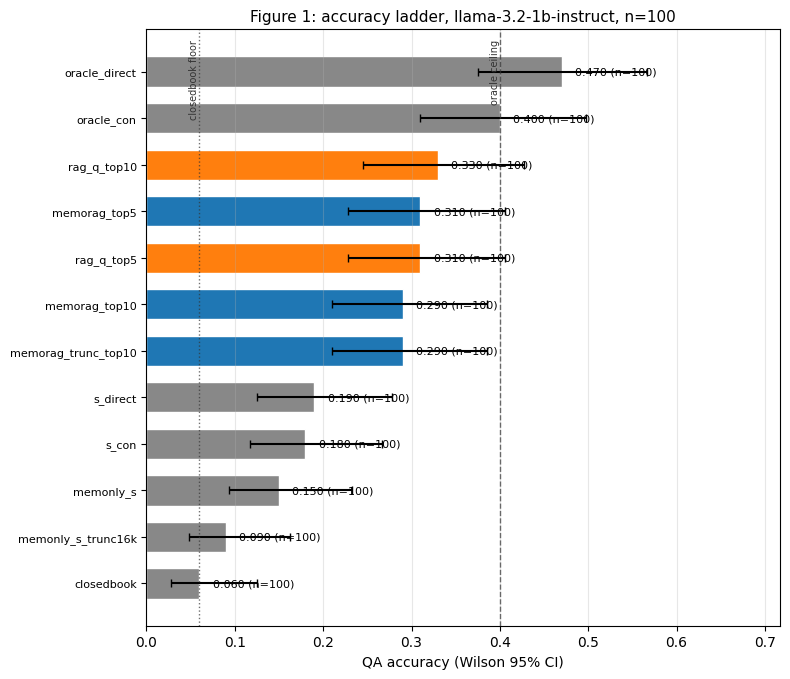

In [30]:
import matplotlib.pyplot as plt

COLOR_MEMORAG = "#1f77b4"
COLOR_RAGQ    = "#ff7f0e"
COLOR_BASE    = "#888888"
COLOR_REF     = "#333333"

def _bar_color(name):
    if "memorag" in name:
        return COLOR_MEMORAG
    if "rag_q" in name or name.startswith("tab3_") and "_q_" in name:
        return COLOR_RAGQ
    return COLOR_BASE


def report_fig1_headline():
    print("=" * 100)
    print("Figure 1: headline accuracy ladder -- every core arm")
    print("=" * 100)
    core_arms = [n for n, a in ARMS.items() if a.artifact == "core"]
    rows = []
    for name in core_arms:
        acc, k, n = accuracy(name)
        if acc is None:
            continue
        _, lo, hi = wilson(k, n)
        rows.append(dict(arm=name, acc=acc, lo=lo, hi=hi, n=n))
    df = pd.DataFrame(rows).sort_values("acc", ascending=True).reset_index(drop=True)
    if df.empty:
        print("  no judged results yet -- run Sections 14-15 first"); return df

    fig, ax = plt.subplots(figsize=(8, 0.45 * len(df) + 1.5))
    colors = [_bar_color(n) for n in df.arm]
    y = np.arange(len(df))
    ax.barh(y, df.acc, xerr=[df.acc - df.lo, df.hi - df.acc], color=colors,
           capsize=3, edgecolor="white", height=0.65)
    for yi, (acc, n) in enumerate(zip(df.acc, df.n)):
        ax.text(acc + 0.015, yi, f"{acc:.3f} (n={n})", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels(df.arm, fontsize=8)
    ax.set_xlim(0, min(1.0, df.hi.max() + 0.15))
    ax.set_xlabel("QA accuracy (Wilson 95% CI)")
    ax.set_title(f"Figure 1: accuracy ladder, {PRIMARY_READER}, n={df.n.max()}", fontsize=11)
    for arm_name, style, label in [("oracle_con", "--", "oracle ceiling"),
                                    ("closedbook", ":", "closedbook floor")]:
        acc, _, _ = accuracy(arm_name)
        if acc is not None:
            ax.axvline(acc, color=COLOR_REF, linestyle=style, linewidth=1, alpha=0.7)
            ax.text(acc, len(df) - 0.3, label, rotation=90, fontsize=7, va="top", ha="right", color=COLOR_REF)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.savefig(RESULTS / "fig1_headline.png", dpi=200); plt.show()
    df.to_csv(RESULTS / "fig1_headline.csv", index=False)
    return df

fig1_df = report_fig1_headline()


## Section 18: Figure 2 -- where MemoRAG helps

Diverging bars centred at 0: `memorag_top10 - rag_q_top10` accuracy delta **per question type**,
with the paired exact McNemar *p*-value for that type printed on the bar. This is the pre-registered
place to look for a real effect (Section 22's audit of `new_method.ipynb`): multi-session,
knowledge-update and preference questions, where an answer depends on synthesizing across sessions
the question text alone may not obviously name -- as opposed to single-session-user/assistant
questions, whose answer session the question already all but names.


Figure 2: where memorag_top10 helps relative to rag_q_top10, by question type


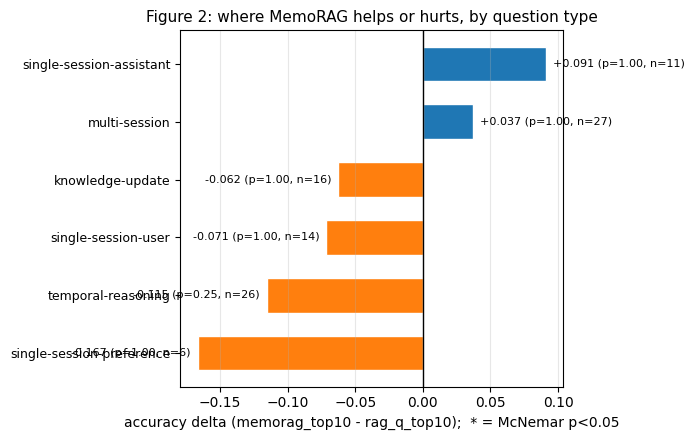

In [31]:
def report_fig2_where_it_helps(arm_a="memorag_top10", arm_b="rag_q_top10"):
    print("=" * 100)
    print(f"Figure 2: where {arm_a} helps relative to {arm_b}, by question type")
    print("=" * 100)
    lab_a, lab_b = arm_labels(arm_a), arm_labels(arm_b)
    common = [q for q in lab_a if q in lab_b]
    if not common:
        print("  no judged overlap between the two arms yet"); return pd.DataFrame()

    rows = []
    for qtype in sorted(EXPECTED_QTYPES):
        qs = [q for q in common if QID2S[q]["question_type"] == qtype]
        if not qs:
            continue
        a_acc = np.mean([1 if lab_a[q] else 0 for q in qs])
        b_acc = np.mean([1 if lab_b[q] else 0 for q in qs])
        _, _, p = mcnemar_exact([lab_a[q] for q in qs], [lab_b[q] for q in qs])
        rows.append(dict(question_type=qtype, n=len(qs), delta=a_acc - b_acc, p=p,
                         memorag_acc=a_acc, rag_q_acc=b_acc))
    df = pd.DataFrame(rows).sort_values("delta")
    if df.empty:
        print("  no per-type overlap"); return df

    fig, ax = plt.subplots(figsize=(7, 0.5 * len(df) + 1.5))
    colors = [COLOR_MEMORAG if d >= 0 else COLOR_RAGQ for d in df.delta]
    y = np.arange(len(df))
    ax.barh(y, df.delta, color=colors, edgecolor="white", height=0.6)
    for yi, (d, p, n) in enumerate(zip(df.delta, df.p, df.n)):
        star = "*" if p < 0.05 else ""
        ax.text(d + (0.005 if d >= 0 else -0.005), yi, f"{d:+.3f}{star} (p={p:.2f}, n={n})",
               va="center", ha="left" if d >= 0 else "right", fontsize=8)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(df.question_type, fontsize=9)
    ax.set_xlabel(f"accuracy delta ({arm_a} - {arm_b});  * = McNemar p<0.05")
    ax.set_title("Figure 2: where MemoRAG helps or hurts, by question type", fontsize=11)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.savefig(RESULTS / "fig2_where_it_helps.png", dpi=200); plt.show()
    df.to_csv(RESULTS / "fig2_where_it_helps.csv", index=False)
    return df

fig2_df = report_fig2_where_it_helps()


## Section 19: Figure 3 -- retrieval vs. reading (the diagnostic)

For each retrieval arm, splits every question into the 2x2 of {an evidence session was actually
retrieved?} x {the reader answered correctly?}. This separates two different explanations for a
result: "RWKV found better evidence" (more mass in `R & G`, less in `notR & notG`) versus "RWKV
helped the reader use evidence it already had" (mass shifts from `R & notG` to `R & G` without
`notR & G` changing). Stacked 100% bars, cells labelled -- the single most diagnostic figure here,
Figure 14's analogue in `longmemeval_recreation.ipynb`.


Figure 3: retrieval-correct x generation-correct, per arm


/usr/local/lib/python3.13/dist-packages/transformers/modeling_attn_mask_utils.py:464: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


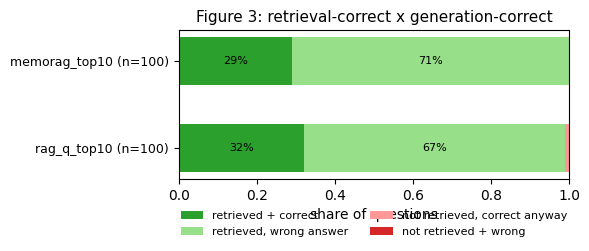

In [32]:
def report_fig3_retrieval_vs_generation(arm_names=("rag_q_top10", "memorag_top10")):
    print("=" * 100)
    print("Figure 3: retrieval-correct x generation-correct, per arm")
    print("=" * 100)
    rows = []
    for arm_name in arm_names:
        arm = ARMS[arm_name]
        lab = arm_labels(arm_name)
        if not lab:
            continue
        buckets = Counter()
        for qid, g in lab.items():
            q = QID2S[qid]
            correct_ids = evidence_ids(q, arm.granularity)
            if not correct_ids:
                continue
            # select_chunks already applies the arm's own top-k/budget cut; match its picked
            # (date, value) chunks back to corpus ids to see which ones made the final cut.
            chunks, ids = select_chunks(q, arm)
            picked_dates = {d for d, _ in chunks}
            # match picked chunks back to ids by (date, value) pair via corpus id order
            corpus_ids, corpus_values, corpus_keys, corpus_dates = build_corpus(q, arm.granularity)
            id_by_date_val = {}
            for cid, val, dt in zip(corpus_ids, corpus_values, corpus_dates):
                id_by_date_val.setdefault((dt, json.dumps(val)), cid)
            retrieved = {id_by_date_val.get((d, json.dumps(v))) for d, v in chunks}
            retrieved.discard(None)
            r_ok = bool(retrieved & correct_ids)
            buckets[("R" if r_ok else "notR") + ("G" if g else "notG")] += 1
        total = sum(buckets.values()) or 1
        rows.append(dict(arm=arm_name, **{k: v / total for k, v in buckets.items()}, n=total))
    df = pd.DataFrame(rows)
    if df.empty:
        print("  no judged results yet"); return df
    for col in ("RG", "RnotG", "notRG", "notRnotG"):
        if col not in df.columns:
            df[col] = 0.0
    df = df.fillna(0.0)

    fig, ax = plt.subplots(figsize=(6, 0.6 * len(df) + 1.5))
    y = np.arange(len(df))
    left = np.zeros(len(df))
    segs = [("RG", "#2ca02c", "retrieved + correct"), ("RnotG", "#98df8a", "retrieved, wrong answer"),
            ("notRG", "#ff9896", "not retrieved, correct anyway"), ("notRnotG", "#d62728", "not retrieved + wrong")]
    for col, color, label in segs:
        vals = df[col].values
        ax.barh(y, vals, left=left, color=color, label=label, height=0.55)
        for yi, (v, l) in enumerate(zip(vals, left)):
            if v > 0.04:
                ax.text(l + v / 2, yi, f"{v:.0%}", va="center", ha="center", fontsize=8, color="black")
        left += vals
    ax.set_yticks(y); ax.set_yticklabels([f"{a} (n={n})" for a, n in zip(df.arm, df.n)], fontsize=9)
    ax.set_xlim(0, 1); ax.set_xlabel("share of questions")
    ax.set_title("Figure 3: retrieval-correct x generation-correct", fontsize=11)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8, frameon=False)
    plt.tight_layout(); plt.savefig(RESULTS / "fig3_retrieval_vs_generation.png", dpi=200, bbox_inches="tight")
    plt.show()
    df.to_csv(RESULTS / "fig3_retrieval_vs_generation.csv", index=False)
    return df

fig3_df = report_fig3_retrieval_vs_generation()


## Section 20: Figure 4 -- accuracy vs. retrieved-token budget

MemoRAG vs. question-only RAG across a tight-to-generous evidence budget sweep. This is where a
memory model should help most: at a tight budget, picking the *right* few sessions matters far more
than at a generous one where both arms can include most of the haystack anyway.


Figure 4: accuracy vs. retrieved-token budget, MemoRAG vs. question-only RAG


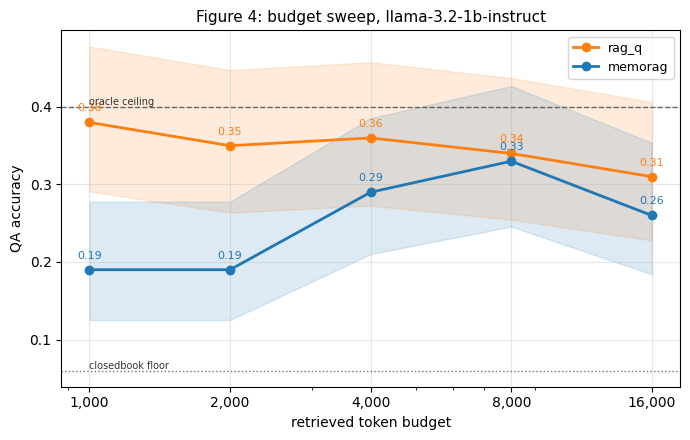

In [33]:
def report_fig4_budget_sweep():
    print("=" * 100)
    print("Figure 4: accuracy vs. retrieved-token budget, MemoRAG vs. question-only RAG")
    print("=" * 100)
    budgets = (1000, 2000, 4000, 8000, 16000)
    rows = []
    for label in ("rag_q", "memorag"):
        for b in budgets:
            acc, k, n = accuracy(f"fig5_{label}_b{b}")
            if acc is None:
                continue
            _, lo, hi = wilson(k, n)
            rows.append(dict(label=label, budget=b, acc=acc, lo=lo, hi=hi, n=n))
    df = pd.DataFrame(rows)
    if df.empty:
        print("  no judged results yet"); return df

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for label, color in (("rag_q", COLOR_RAGQ), ("memorag", COLOR_MEMORAG)):
        sub = df[df.label == label].sort_values("budget")
        if sub.empty:
            continue
        ax.plot(sub.budget, sub.acc, marker="o", color=color, label=label, linewidth=2)
        ax.fill_between(sub.budget, sub.lo, sub.hi, color=color, alpha=0.15)
        for x, y in zip(sub.budget, sub.acc):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 8),
                       fontsize=8, ha="center", color=color)
    for arm_name, style, ref_label in [("oracle_con", "--", "oracle ceiling"),
                                        ("closedbook", ":", "closedbook floor")]:
        acc, _, _ = accuracy(arm_name)
        if acc is not None:
            ax.axhline(acc, color=COLOR_REF, linestyle=style, linewidth=1, alpha=0.7)
            ax.text(budgets[0], acc, ref_label, fontsize=7, va="bottom", color=COLOR_REF)
    ax.set_xscale("log"); ax.set_xticks(budgets); ax.set_xticklabels([f"{b:,}" for b in budgets])
    ax.set_xlabel("retrieved token budget"); ax.set_ylabel("QA accuracy")
    ax.set_title(f"Figure 4: budget sweep, {PRIMARY_READER}", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(RESULTS / "fig4_budget_sweep.png", dpi=200); plt.show()
    df.to_csv(RESULTS / "fig4_budget_sweep.csv", index=False)
    return df

fig4_df = report_fig4_budget_sweep()


## Section 21: Figure 5 -- query design x granularity (retrieval + end-to-end QA)

Which memory-model output actually carries the gain: the raw question alone, `+sur` (surrogate
questions), `+span` (recalled text spans), or their combination, at session or round granularity.
Retrieval metrics (Recall@10, NDCG@10) come free from the corpus -- no reader, no judge needed --
so they are computed for **both** retrievers (Stella, BM25), giving a Table-9-style retriever
ablation at no extra generation cost; end-to-end QA accuracy comes from the judged `tab3_*` arms
(Stella only, matching the arms actually generated in Section 12).


Figure 5: query design x granularity -- retrieval metrics (both retrievers) + QA accuracy


/usr/local/lib/python3.13/dist-packages/transformers/modeling_attn_mask_utils.py:464: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



Retrieval-only metrics (Table 9 analogue, no reader/judge needed):
retriever granularity       design  recall5  recall10  ndcg10
   stella     session            q    0.979     0.989   0.974
   stella     session          sur    0.853     0.968   0.862
   stella     session         span    0.800     1.000   0.838
   stella     session     sur+span    0.758     0.947   0.765
   stella     session sur+span+ans    0.768     0.926   0.760
   stella       round            q    0.632     0.800   0.694
   stella       round          sur    0.432     0.674   0.557
   stella       round         span    0.411     0.632   0.550
   stella       round     sur+span    0.326     0.611   0.481
   stella       round sur+span+ans    0.326     0.611   0.476
     bm25     session            q    0.842     0.884   0.911
     bm25     session          sur    0.779     0.926   0.800
     bm25     session         span    0.768     0.895   0.784
     bm25     session     sur+span    0.674     0.884   0.705
  

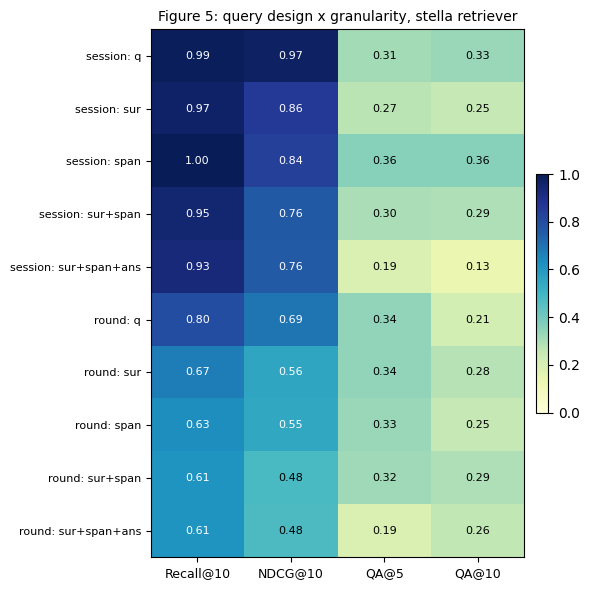

In [34]:
DESIGNS = ["", "sur", "span", "sur+span", "sur+span+ans"]

def retrieval_only_metrics(retriever, qids=None):
    qids = [q for q in (qids or QUESTION_IDS) if not q.endswith("_abs")]
    rows = []
    for gran in ("session", "round"):
        for design in DESIGNS:
            r5a, r10a, nd10 = [], [], []
            for qid in qids:
                q = QID2S[qid]
                ids, values, keys, stamps = build_corpus(q, gran)
                correct = evidence_ids(q, gran)
                if not correct:
                    continue
                queries = build_query_set(qid, design, "s")
                rankings = [get_retriever(retriever).rank(qq, keys) for qq in queries]
                ranking = fuse(rankings, len(ids), "rank", len(ids))
                _, ra5, _ = evaluate_retrieval(ranking, correct, ids, k=5)
                _, ra10, n10 = evaluate_retrieval(ranking, correct, ids, k=10)
                r5a.append(ra5); r10a.append(ra10); nd10.append(n10)
            rows.append(dict(retriever=retriever, granularity=gran, design=design or "q",
                             recall5=np.mean(r5a) if r5a else np.nan,
                             recall10=np.mean(r10a) if r10a else np.nan,
                             ndcg10=np.mean(nd10) if nd10 else np.nan))
    return pd.DataFrame(rows)


def report_fig5_query_design():
    print("=" * 100)
    print("Figure 5: query design x granularity -- retrieval metrics (both retrievers) + QA accuracy")
    print("=" * 100)
    if not CAN_RUN_EMBEDDINGS:
        print("  SKIP: embeddings unavailable on this GPU."); return pd.DataFrame()

    metric_frames = [retrieval_only_metrics(r) for r in RETRIEVERS]
    save_all_retriever_caches()   # this sweep re-embeds every (granularity, design) combination
                                   # across all 500 questions -- persist it, same as Gate 4/Stage C
    metrics_df = pd.concat(metric_frames, ignore_index=True)
    metrics_df.to_csv(RESULTS / "table9_retrieval_only.csv", index=False)
    print("\nRetrieval-only metrics (Table 9 analogue, no reader/judge needed):")
    with pd.option_context("display.width", 160):
        print(metrics_df.round(3).to_string(index=False))

    qa_rows = []
    for gran in ("session", "round"):
        for design in DESIGNS:
            tag = design.replace("+", "_") or "q"
            for k in (5, 10):
                acc, _, n = accuracy(f"tab3_{gran}_{tag}_top{k}")
                qa_rows.append(dict(granularity=gran, design=design or "q", topk=k, acc=acc, n=n))
    qa_df = pd.DataFrame(qa_rows)
    qa_df.to_csv(RESULTS / "table3_qa.csv", index=False)

    # Heatmap: rows = design x granularity, columns = recall10 / ndcg10 (stella) / QA@5 / QA@10
    stella_metrics = metrics_df[metrics_df.retriever == PRIMARY_DENSE_RETRIEVER]
    heat_rows, row_labels = [], []
    for gran in ("session", "round"):
        for design in DESIGNS:
            tag = design or "q"
            m = stella_metrics[(stella_metrics.granularity == gran) & (stella_metrics.design == tag)]
            qa5 = qa_df[(qa_df.granularity == gran) & (qa_df.design == tag) & (qa_df.topk == 5)]["acc"]
            qa10 = qa_df[(qa_df.granularity == gran) & (qa_df.design == tag) & (qa_df.topk == 10)]["acc"]
            heat_rows.append([
                float(m.recall10.iloc[0]) if len(m) else np.nan,
                float(m.ndcg10.iloc[0]) if len(m) else np.nan,
                float(qa5.iloc[0]) if len(qa5) and qa5.iloc[0] is not None else np.nan,
                float(qa10.iloc[0]) if len(qa10) and qa10.iloc[0] is not None else np.nan,
            ])
            row_labels.append(f"{gran}: {tag}")
    heat = np.array(heat_rows, dtype=float)

    fig, ax = plt.subplots(figsize=(6, 0.45 * len(row_labels) + 1.5))
    im = ax.imshow(heat, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(["Recall@10", "NDCG@10", "QA@5", "QA@10"], fontsize=9)
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            v = heat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                       color="white" if v > 0.55 else "black")
    ax.set_title(f"Figure 5: query design x granularity, {PRIMARY_DENSE_RETRIEVER} retriever", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
    plt.tight_layout(); plt.savefig(RESULTS / "fig5_query_design_heatmap.png", dpi=200); plt.show()
    return metrics_df, qa_df

fig5_metrics_df, fig5_qa_df = report_fig5_query_design()


## Section 22: Figure 6 -- reading strategy and query-fusion strategy

Two small panels sharing one y-axis. **Left** (Figure 6 analogue): MemoRAG's accuracy under
`{direct, con}` reading x `{json, nl}` history formatting. **Right** (Table 10 analogue): the three
fusion strategies from Section 11 (`rank` = equal-budget best-rank fusion, `rrf` = reciprocal-rank
fusion, `union_literal` = MemoRAG's actual literal union-of-top-k, which is not budget-capped and so
is expected to look different in kind, not just degree, from the other two -- see Section 22's
deviation #4).


Figure 6: reading strategy (left) and query-fusion strategy (right)


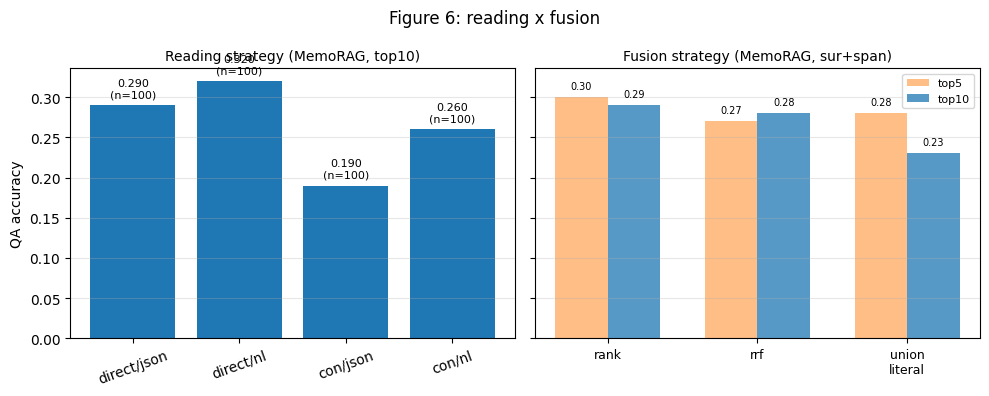

In [35]:
def report_fig6_reading_and_fusion():
    print("=" * 100)
    print("Figure 6: reading strategy (left) and query-fusion strategy (right)")
    print("=" * 100)
    reading_rows = []
    for reading in ("direct", "con"):
        for fmt in ("json", "nl"):
            name = "memorag_top10" if (reading, fmt) == ("direct", "json") else f"fig6_{reading}_{fmt}"
            acc, k, n = accuracy(name)
            reading_rows.append(dict(reading=reading, format=fmt, acc=acc, n=n))
    reading_df = pd.DataFrame(reading_rows)

    fusion_rows = []
    for fusion in ("rank", "rrf", "union_literal"):
        for k in (5, 10):
            acc, kk, n = accuracy(f"tab10_{fusion}_top{k}")
            fusion_rows.append(dict(fusion=fusion, topk=k, acc=acc, n=n))
    fusion_df = pd.DataFrame(fusion_rows)

    reading_df.to_csv(RESULTS / "fig6_reading_strategy.csv", index=False)
    fusion_df.to_csv(RESULTS / "table10_fusion_strategy.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    ax = axes[0]
    labels = [f"{r}/{f}" for r, f in zip(reading_df.reading, reading_df.format)]
    vals = [v if v is not None else 0 for v in reading_df.acc]
    bars = ax.bar(labels, vals, color=COLOR_MEMORAG)
    for b, v, n in zip(bars, reading_df.acc, reading_df.n):
        if v is not None:
            ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}\n(n={n})", ha="center", fontsize=8)
    ax.set_title("Reading strategy (MemoRAG, top10)", fontsize=10)
    ax.set_ylabel("QA accuracy"); ax.tick_params(axis="x", rotation=20)

    ax = axes[1]
    x = np.arange(3); width = 0.35
    for i, k in enumerate((5, 10)):
        sub = fusion_df[fusion_df.topk == k]
        vals = [v if v is not None else 0 for v in sub.acc]
        bars = ax.bar(x + (i - 0.5) * width, vals, width, label=f"top{k}",
                      color=COLOR_MEMORAG if k == 10 else COLOR_RAGQ, alpha=0.5 + 0.25 * i)
        for xi, v, n in zip(x + (i - 0.5) * width, sub.acc, sub.n):
            if v is not None:
                ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(["rank", "rrf", "union\nliteral"], fontsize=9)
    ax.set_title("Fusion strategy (MemoRAG, sur+span)", fontsize=10)
    ax.legend(fontsize=8)

    for ax in axes:
        ax.grid(axis="y", alpha=0.3)
    plt.suptitle("Figure 6: reading x fusion", fontsize=12)
    plt.tight_layout(); plt.savefig(RESULTS / "fig6_reading_fusion.png", dpi=200); plt.show()
    return reading_df, fusion_df

fig6_reading_df, fig6_fusion_df = report_fig6_reading_and_fusion()


## Section 23: Provenance, deviations, cost, and extending to other readers

### Comparison to `longmemeval_recreation.ipynb`

`longmemeval_recreation.ipynb`'s Table 8 row for `llama-3.2-1b-instruct`: oracle **0.386**,
LongMemEval_S (no retrieval) **0.010**, S with retrieval (K=V) **0.312**. The cell below prints
this notebook's own `oracle_con`, `s_con`, and `rag_q_top10`/`memorag_top10` numbers alongside
those three for a direct sanity check -- `oracle_con` and `s_con` should land close to 0.386 and
0.010 respectively (same reader, same dataset, same reading style); if either is far off, the
harness has a bug, not the hypothesis.


In [36]:
PAPER_TABLE8_LLAMA1B = dict(oracle=0.386, s=0.010, s_kv=0.312)   # from Table 8, K=V column

def report_sanity_vs_recreation():
    print("=" * 100)
    print("Sanity check against longmemeval_recreation.ipynb's Table 8 (llama-3.2-1b-instruct)")
    print("=" * 100)
    rows = []
    for name, ref in [("oracle_con", PAPER_TABLE8_LLAMA1B["oracle"]),
                      ("s_con", PAPER_TABLE8_LLAMA1B["s"]),
                      ("rag_q_top10", PAPER_TABLE8_LLAMA1B["s_kv"])]:
        acc, k, n = accuracy(name)
        rows.append(dict(arm=name, this_notebook=acc, recreation_reference=ref, n=n))
    df = pd.DataFrame(rows)
    print(df.round(3).to_string(index=False))
    print("\n  (recreation_reference values are from longmemeval_recreation.ipynb's own n=100 pilot")
    print("  run -- not identical questions, so exact agreement isn't expected, only rough agreement.)")
    df.to_csv(RESULTS / "sanity_vs_recreation.csv", index=False)
    return df

report_sanity_vs_recreation()


Sanity check against longmemeval_recreation.ipynb's Table 8 (llama-3.2-1b-instruct)
        arm  this_notebook  recreation_reference   n
 oracle_con           0.40                 0.386 100
      s_con           0.18                 0.010 100
rag_q_top10           0.33                 0.312 100

  (recreation_reference values are from longmemeval_recreation.ipynb's own n=100 pilot
  run -- not identical questions, so exact agreement isn't expected, only rough agreement.)


,arm,this_notebook,recreation_reference,n
0,oracle_con,0.40,0.386,100
1,s_con,0.18,0.010,100
2,rag_q_top10,0.33,0.312,100


### Known deviations from MemoRAG's and LongMemEval's exact methodology

1. **The memory model is off-the-shelf, not trained.** MemoRAG trains its memory model (context
   compression via `memorag-qwen2-7b-inst`). RWKV-7 G1 2.9B is a general-purpose checkpoint used
   as-is -- the thing this notebook is testing, not an oversight.
2. **Memory is loaded by state-feeding, MemoRAG's own `context` prompt is not used.** The three
   task prompts (`sur`/`span`/`qa`) are verbatim (Gate 2b); only the delivery mechanism differs, per
   Section 10's design note.
3. **RWKV-7 G1's trained context is 16,384 tokens; the primary `s` memory source feeds ~115k
   tokens, ~7x beyond it.** The `s_trunc16k` memory source and its `memonly_s_trunc16k` /
   `memorag_trunc_top10` arms exist precisely to separate "the memory mechanism doesn't help" from
   "115k tokens overruns this checkpoint's trained capacity" -- compare `memorag_top10` against
   `memorag_trunc_top10` in Figure 1 before concluding either way.
4. **Equal-budget rank fusion (`fusion="rank"`) is the headline arms' default, not MemoRAG's own
   literal union-then-corpus-order `_retrieve()`.** With ~5 queries x top-10 over a ~47-session
   haystack, the literal union would return most of the haystack, collapsing any MemoRAG arm toward
   the `s` baseline and making a "win" an artifact of showing the reader more text rather than
   better text. The literal path is retained as `tab10_union_literal_*`, where it belongs.
5. **LongMemEval_S, not M** -- same scoping decision as `longmemeval_recreation.ipynb`.
6. **`build_corpus()`'s key-text construction is a reimplementation, not a verbatim transcription**
   of `longmemeval_recreation.ipynb`'s own `dialogue_string()` helper (that notebook's Section 10,
   not reproduced here) -- both concatenate only the user-side turn content of a session/round;
   the exact formatting may differ in minor ways (e.g. separators).
7. **Top-k grids, budget grids, and the query-design ladder are ours** -- neither paper states them.
8. **The judge is OpenAI sync mode, not the Batch API** -- same model and prompts as both papers,
   only the transport (and, at this question count, the cost) differs from a batch-priced run.

### Audit of `new_method.ipynb` (an earlier, narrower attempt at this idea)

`new_method.ipynb` (Section 29.16-29.26 of `long_mem_eval_v1.ipynb`'s lineage) is **correct where
it counts**: `render_session()` strips `has_answer` before both BM25 indexing and prompt rendering
(no evidence leak), `retrieve_topk` breaks ties deterministically, `build_retrieval_prompt` asserts
the prompt fits the token budget. Nothing there is broken.

But it does not implement MemoRAG's actual mechanism, in three ways this notebook fixes:

1. **It drops the raw question.** `rwkvmem-retrieval` queries BM25 with RWKV's note *instead of*
   the question. MemoRAG's `_prepare_retrieval_query` (Gate 2b, Section 8) **always** appends the
   raw query -- replacing it rather than augmenting it makes that arm a strictly weaker ablation.
2. **It implements only the off-by-default branch.** Its `Facts:/Answer:` note corresponds to
   MemoRAG's `answer()` / `use_memory_answer=True`, which **defaults to False**. The two
   *default* clue sources -- `rewrite()` (surrogate questions, `sur`) and `recall()` (text spans,
   `span`) -- are absent from it; this notebook's `build_query_set()` implements both.
3. **Single-query retrieval, no fusion.** MemoRAG's signal is a multi-query union; `new_method.ipynb`
   issues one BM25 query per arm.

Worth carrying forward from it: its measured **20/20** sample questions where plain-question BM25's
top-10 contained an oracle session is a genuine ceiling-effect warning -- consistent with Gate 3's
own (smaller) sample above, and the reason the query-design sweep (Section 21 / `tab3_*`) includes
small k where headroom for a better query still exists, and a null result there is a legitimate,
pre-registered possible outcome, not evidence of a bug.

### Note on the RWKV checkpoint

`RWKV/RWKV7-2.9B-20260805` (the HF repo named in the original request) is the safetensors
conversion of `BlinkDL/rwkv7-g1/rwkv7-g1i-2.9b-20260805-ctx16384.pth` -- the **same weights**
`long_mem_eval_v1.ipynb` Section 29 already validated on Colab. This notebook uses the proven
`.pth`/`rwkv`-package path (working `feed()`/`probe_memory()`, fused CUDA kernel, explicit state
passing) rather than the HF/`transformers` safetensors path, with no loss of fidelity to the
requested model -- same weights, different loader.

### Extending to the recreation notebook's other four readers

`READERS` (Section 3) is the only thing that needs to grow. For an OpenRouter-routed reader (as
`longmemeval_recreation.ipynb` uses for `llama-3.2-3b-instruct`, `qwen-2.5-7b-instruct`,
`llama-3.1-8b-instruct`), add an entry with `route="openrouter"` and swap `LocalVLLMBackend` in
Section 14 for that notebook's own `OpenRouterBackend` (transcribed there, not reproduced here to
keep this notebook's dependency surface minimal for a single local reader). Everything upstream of
generation -- RWKV memory (Section 10), retrieval (Section 11), the arm registry (Section 12) -- is
**already reader-independent**: Stage A and Stage B's outputs on Drive are reused unchanged, so
adding a reader costs only Stages C-D, not a re-run of the expensive RWKV stage.


In [37]:
def cost_ledger():
    print("=" * 90)
    print("Cost and volume ledger (measured from the run records, not estimated)")
    print("=" * 90)
    agg = {}
    for r in iter_generations():
        k = (r.get("reader", "?"), r.get("artifact", "?"))
        a = agg.setdefault(k, dict(n=0, pin=0, pout=0, lat=0.0, err=0))
        a["n"] += 1; a["pin"] += r.get("prompt_tokens", 0) or 0; a["pout"] += r.get("completion_tokens", 0) or 0
        a["lat"] += r.get("latency_s", 0.0) or 0.0; a["err"] += 1 if r.get("error") else 0
    if not agg:
        print("  no generations on disk yet"); return None
    rows = [dict(reader=k[0], artifact=k[1], n=v["n"], in_Mtok=v["pin"] / 1e6, out_Mtok=v["pout"] / 1e6,
                mean_latency_s=v["lat"] / max(1, v["n"]), errors=v["err"]) for k, v in sorted(agg.items())]
    df = pd.DataFrame(rows)
    print(df.round(3).to_string(index=False))

    n_judged = len(JUDGED) if "JUDGED" in globals() else 0
    judge_cost = n_judged * 400 / 1e6 * 2.50
    rwkv_rows = 0
    for src in MEMORY_SOURCES:
        rwkv_rows += len(load_memory(src)) if CAN_RUN_RWKV else 0
    print(f"\n  generation:                      local (vLLM), GPU time, not billed per token")
    print(f"  RWKV memory-building:             local, GPU time, not billed per token "
          f"({rwkv_rows} memory rows across {len(MEMORY_SOURCES)} sources)")
    print(f"  judge ({n_judged:,} calls, sync GPT-4o): ${judge_cost:8.2f}  (estimated at ~400 tok/call)")
    print(f"  {'-' * 52}")
    print(f"  TOTAL API SPEND SO FAR:          ${judge_cost:8.2f}")
    df.to_csv(RESULTS / "cost_ledger.csv", index=False)
    return df

cost_ledger()

print("\n" + "=" * 90)
print("Results written to:", RESULTS)
for p in sorted(RESULTS.glob("*")):
    print(" ", p.name)


Cost and volume ledger (measured from the run records, not estimated)
               reader artifact    n  in_Mtok  out_Mtok  mean_latency_s  errors
llama-3.2-1b-instruct     core 1200   35.312     0.097           1.502       0
llama-3.2-1b-instruct     fig5 1000    8.705     0.058           0.223       0
llama-3.2-1b-instruct     fig6  300    7.467     0.050           0.816       0
llama-3.2-1b-instruct    tab10  600   19.122     0.032           1.071       0
llama-3.2-1b-instruct     tab3 2000   24.748     0.109           0.321       0

  generation:                      local (vLLM), GPU time, not billed per token
  RWKV memory-building:             local, GPU time, not billed per token (200 memory rows across 2 sources)
  judge (5,100 calls, sync GPT-4o): $    5.10  (estimated at ~400 tok/call)
  ----------------------------------------------------
  TOTAL API SPEND SO FAR:          $    5.10

Results written to: /content/drive/MyDrive/lme_memorag/results
  cost_ledger.csv
  fig1_h